# Live-Demo: N-BEATS
## Forecast des Strombedarfs & Vergleich mit klassischen Modellen

**Ziel dieser Demo:** Prognose des Strombedarfs (`Electric_demand`) mit **N-BEATS**, einem reinen Deep-Learning-Modell für Zeitreihen, und der direkte Vergleich mit den klassischen Modellen **ARIMA, SARIMA und SARIMAX**.
<br>Aufbauend darauf zeigen wir zwei Erweiterungen:
- **N-BEATSx** (nutzt zusätzlich exogene Variablen)
- **Interpretierbares N-BEATS** (zerlegt den Forecast in Trend + Saison)

**Was ist N-BEATS?**\
N-BEATS (*Neural Basis Expansion Analysis for Time Series*, Oreshkin et al. 2019) ist ein rein vorwärtsgerichtetes neuronales Netz, das eine Zeitreihe ausschließlich aus ihrer eigenen Vergangenheit prognostiziert. Ohne Rekurrenz (kein *Long Short-Term Memory*), ohne Attention und ohne manuelle Merkmalskonstruktion.

**Leitfrage der Demo:**

> ❓ Kann ein universelles neuronales Netz, das **ohne** manuelle Stationaritäts- und Saisonalitätsanalyse auskommt, die Prognosequalität der klassischen (S)ARIMA(X)-Modelle erreichen oder übertreffen?

**Fahrplan:**

| Abschnitt | Inhalt |
|---|---|
| 1 – 2 | Daten laden & identischer Train/Test-Split wie in der SARIMAX-Demo |
| 3 | N-BEATS: Idee, Architektur, Training (Seed-Ensemble) |
| 4 | Vergleich mit ARIMA/SARIMA/SARIMAX |
| 5 | **N-BEATSx** – Erweiterung um exogene Variablen |
| 6 | **Interpretable N-BEATS** – zerlegbarer Forecast (Trend + Saison) |
| 7 | Robustheits-Check: Walk-forward-Backtest |
| 8 | Fazit: Die wichtigsten Erkenntnisse |

<br>

> ⚖️ **Wichtig für die Einordnung:** <br> N-BEATS ist – wie ARIMA und SARIMA – ein **univariates** Modell. Es nutzt nur die Vergangenheit des Strombedarfs, **keine** exogenen Variablen. Der fairste Vergleichspartner ist daher **SARIMA**. SARIMAX hat durch die exogenen Variablen einen strukturellen Vorteil.

## Imports

In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
from torch.utils.data import DataLoader, TensorDataset

# GPU nutzen, falls verfügbar (sonst CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__, "| Device:", device)

PyTorch: 2.6.0+cu124 | Device: cuda


In [2]:
# Einheitlicher Plot-Stil für gesamte Demo
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": True, "axes.spines.right": True,         # vollständig umrandeter Plotbereich
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.9,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.labelsize": 11, "axes.labelcolor": "#52514e",
    "axes.grid": True, "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "axes.axisbelow": True,                                    # Gridlinien IMMER hinter Balken/Linien

    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.frameon": True, "legend.fontsize": 10,              # Legende mit Hintergrund,
    "legend.facecolor": "#fcfcfb", "legend.framealpha": 0.85, # damit Gridlinien nicht durchscheinen
    "legend.edgecolor": "none",
})

# Feste Farbzuordnung: jedes Modell behält seine Farbe in allen Plots
FARBEN = {
    "Ist":         "#0b0b0b",  # tatsächliche Werte
    "ARIMA":       "#767470",  # grau    – schwächste Baseline
    "SARIMA":      "#2a78d6",  # blau    – klassisch, univariat
    "SARIMAX":     "#1baf7a",  # grün    – klassisch, mit exogenen Variablen
    "N-BEATS":     "#e34948",  # rot     – Deep Learning, univariat
    "N-BEATSx":    "#4a3aa7",  # violett – Deep Learning, mit exogenen Variablen
    "N-BEATS-i":   "#e87ba4",  # magenta – Deep Learning, interpretierbar
    "Training":    "#9ec5f4",  # Lernkurve: Trainingsfehler
    "Validierung": "#eb6834",  # Lernkurve: Validierungsfehler (Holdout)
    "Trend":       "#2a78d6",  # Zerlegung: Trend-Komponente
    "Saison":      "#1baf7a",  # Zerlegung: Saison-Komponente
}

def datum_achse(ax):
    """Kompakte, gut lesbare Datumsbeschriftung für Zeitachsen."""
    loc = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(loc)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))

## 1. Daten laden (Export aus dem SARIMAX-Notebook)

Wir laden die im SARIMAX-Notebook exportierten Dateien aus dem lokalen Ordner `Daten/` (Kopie aus `KlassischeMethod_SARIMAX/vergleichsdaten/`), damit alle Modelle auf **exakt derselben Datenbasis** rechnen:

| Datei | Inhalt |
|---|---|
| `stromdaten_stuendlich.csv` | Stündlich aggregierte Daten (Zielvariable + exogene Variablen) |
| `klassische_rmse.csv` | RMSE der klassischen Modelle |
| `klassische_forecasts.csv` | Forecast-Reihen + tatsächliche Testwerte |
| `split_config.json` | Konfiguration des Train/Test-Splits |

<br>

> ⚠️ Falls diese Dateien fehlen: zuerst das Notebook **`S_ARIMA_X_LiveDemo.ipynb`** vollständig ausführen (erzeugt den Ordner `vergleichsdaten/`) und die vier Dateien in diesen `Daten/`-Ordner kopieren.

In [3]:
# Pfad zu den Vergleichsdaten (Kopie aus dem SARIMAX-Notebook) prüfen und laden
export_dir = Path("Daten")
if not (export_dir / "stromdaten_stuendlich.csv").exists():
    raise FileNotFoundError(
        "Vergleichsdaten nicht gefunden. Bitte zuerst 'S_ARIMA_X_LiveDemo.ipynb' "
        "vollständig ausführen und die Exportdateien in den Ordner 'Daten/' kopieren."
    )

# Stündliche Daten (gleiche Basis wie ARIMA/SARIMA/SARIMAX)
data_hourly = pd.read_csv(export_dir / "stromdaten_stuendlich.csv",
                          index_col="Time", parse_dates=["Time"])

# Ergebnisse & Forecasts der klassischen Modelle
klassische_rmse = pd.read_csv(export_dir / "klassische_rmse.csv")
klassische_forecasts = pd.read_csv(export_dir / "klassische_forecasts.csv",
                                   index_col="Time", parse_dates=["Time"])

# Split-Konfiguration
with open(export_dir / "split_config.json", encoding="utf-8") as f:
    split_config = json.load(f)

target = split_config["target"]
test_days = split_config["test_days"]

print("Zeitraum:", data_hourly.index.min(), "bis", data_hourly.index.max())
print("Beobachtungen (stündlich):", len(data_hourly))
print("Zielvariable:", target, "| Testzeitraum:", test_days, "Tage")
print("\nRMSE der klassischen Modelle:")
print(klassische_rmse.to_string(index=False))

Zeitraum: 2019-01-01 00:00:00 bis 2021-12-31 23:00:00
Beobachtungen (stündlich): 26304
Zielvariable: Electric_demand | Testzeitraum: 14 Tage

RMSE der klassischen Modelle:
 Modell        RMSE
  ARIMA 3017.579568
 SARIMA 2232.700858
SARIMAX 1814.877406


## 2. Train/Test-Split (identisch zur SARIMAX-Demo)

Wir verwenden **denselben** 14-Tage-Testzeitraum am Ende der Reihe wie die klassischen Modelle, nur so ist der RMSE-Vergleich zwischen den Modellfamilien aussagekräftig.

- **Training:** 01.01.2019 bis 17.12.2021 (25 968 Stunden)
- **Test:** die letzten 14 Tage des Jahres 2021 (336 Stunden)

Train: 25968 Stunden  (2019-01-01 00:00:00 ... 2021-12-17 23:00:00)
Test : 336 Stunden  (2021-12-18 00:00:00 ... 2021-12-31 23:00:00)


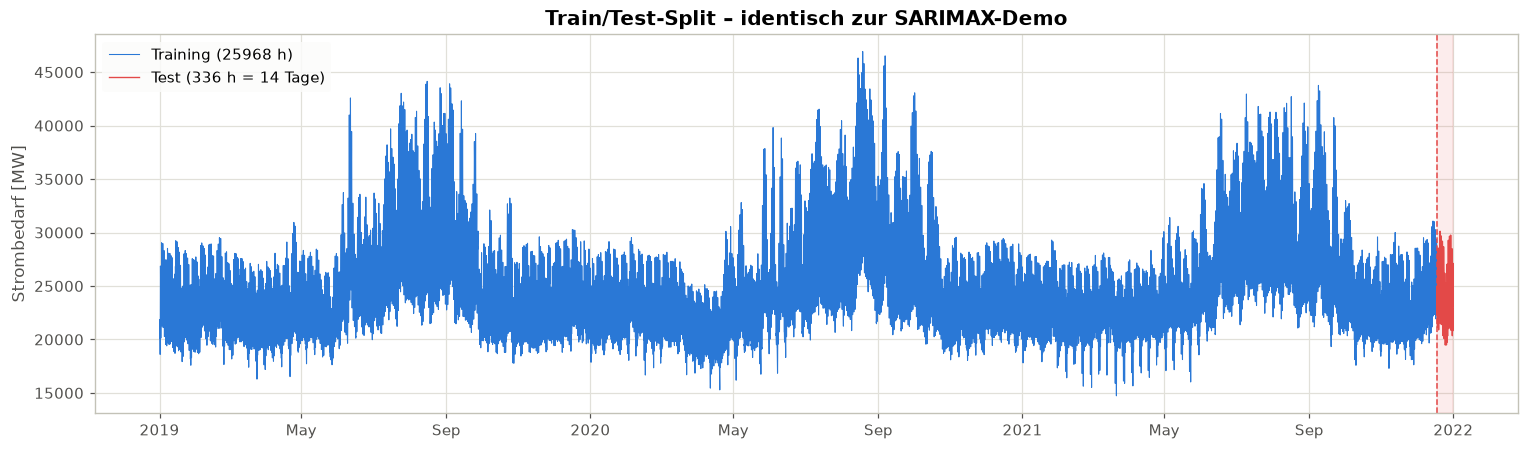

In [4]:
# Die Zielvariable (Electric_demand) in float32 konvertieren, um Speicher zu sparen
# pyTorch arbeitet standardmäßig mit float32, Pandas mit float64 -> daher ist die Konvertierung sinnvoll
y = data_hourly[target].astype("float32")

# Train/Test-Split identisch zur SARIMAX-Demo
test_size = 24 * test_days              # 14 Tage * 24 Stunden = 336 Stunden
y_train = y.iloc[:-test_size]           # Trainingsdaten: alles außer den letzten 336 Stunden
y_test = y.iloc[-test_size:]            # Testdaten: die letzten 336 Stunden

print(f"Train: {len(y_train)} Stunden  ({y_train.index.min()} ... {y_train.index.max()})")
print(f"Test : {len(y_test)} Stunden  ({y_test.index.min()} ... {y_test.index.max()})")

# Visualisierung des Train/Test-Splits
fig, ax = plt.subplots(figsize=(14, 4.2))
ax.plot(y_train.index, y_train.values, color=FARBEN["SARIMA"], linewidth=0.7,
        label=f"Training ({len(y_train)} h)")
ax.plot(y_test.index, y_test.values, color=FARBEN["N-BEATS"], linewidth=0.9,
        label=f"Test ({len(y_test)} h = {test_days} Tage)")
ax.axvspan(y_test.index[0], y_test.index[-1], color=FARBEN["N-BEATS"], alpha=0.10)
ax.axvline(y_test.index[0], color=FARBEN["N-BEATS"], linestyle="--", linewidth=1)
ax.set_ylabel("Strombedarf [MW]")
ax.set_title("Train/Test-Split – identisch zur SARIMAX-Demo")
datum_achse(ax)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 3. N-BEATS – Idee & Architektur

Während (S)ARIMA(X) **explizit** modelliert wird (Stationarität prüfen, differenzieren, $p$/$d$/$q$ und saisonale Ordnung wählen), **lernt** N-BEATS diese Strukturen implizit aus den Daten – es gibt **keine** manuelle Stationaritäts- oder Saisonalitätsanalyse.

### Grundprinzip: Backcast & Forecast

Das Modell bekommt ein Rückblickfenster (*lookback*) der Länge $L$ und gibt **zwei** Dinge aus:

| Ausgabe | Bedeutung |
|---|---|
| **Forecast** $\hat{y}$ | die eigentliche Vorhersage über den Horizont $H$ |
| **Backcast** $\hat{x}$ | eine Rekonstruktion des Eingabefensters – „was habe ich vom Input verstanden?“ |

### Der Block – die Grundeinheit

Ein vollverbundenes MLP (mehrere `Linear`+`ReLU`-Schichten), das in **zwei lineare Projektionen** mündet: eine für den Backcast, eine für den Forecast.

![Aufbau eines N-BEATS-Blocks](Bilder/bilder_nbeats_block.svg)\
*Der FC-Stack verdichtet das Rückblickfenster zu einer gemeinsamen Repräsentation $h$. Daraus lesen zwei separate lineare Köpfe den Backcast (Rekonstruktion der Eingabe) und den Forecast (Vorhersage) ab.*

### Doubly-Residual-Stacking

Mehrere Blöcke werden hintereinandergeschaltet. Jeder Block bearbeitet nur das **Residuum** des vorherigen Blocks.
Der Backcast „erklärt weg“, was ein Block verstanden hat, der nächste Block kümmert sich nur noch um den Rest. Die Forecasts aller Blöcke werden aufsummiert. Das ist ein Boosting-artiges Prinzip und macht das tiefe Netz stabil trainierbar.

![N-BEATS-Architektur](Bilder/bilder_nbeats_architektur.png)\
*(Quelle: Oreshkin et al. 2019, „N-BEATS: Neural Basis Expansion Analysis for Interpretable Time Series Forecasting“)*

### Generisch vs. interpretierbar

- **Generisch**: Die Projektionen sind frei lernbare lineare Schichten.
- **Interpretierbar**: Feste Polynome (Trend) und Fourier-Terme (Saisonalität) machen den Forecast in Trend- und Saison-Komponenten zerlegbar.\
→ Unterscheidung nur durch Wahl der Basisfunktionen $g(\theta)$

### 3.1 Datenaufbereitung: Skalierung & Sliding Windows

Zwei Schritte sind für neuronale Netze wichtig:

1. **Skalierung:** Der Strombedarf liegt im MW-Bereich. Für stabiles Training standardisieren wir mit **Mittelwert und Streuung der Trainingsdaten** (kein Data Leakage aus dem Testzeitraum).
2. **Sliding Windows:** Aus der Trainingsreihe schneiden wir überlappende Fenster mit einer Schrittweite von `STRIDE`: Jeweils `INPUT_SIZE` Stunden Eingabe → die folgenden `HORIZON` Stunden als Ziel.

**Wahl der Fenstergrößen:**

- **Horizont = 336 h** (= Länge des Testzeitraums): N-BEATS prognostiziert – wie SARIMA – den gesamten Testzeitraum **in einem Schritt** (direkter Multi-Step-Forecast).
- **Rückblick = 336 h** (2 Wochen): das kleinste Fenster, das Tages- **und** Wochenmuster vollständig enthält.
> ⚠️ Das Original-Paper empfiehlt zwar längere Rückblicke (2–7 × Horizont) – wir haben 2 × H (672 h) getestet: **kein belastbarer Vorteil**. Auf dem kurzen, schwierigen Testfenster (Feiertage) dominiert die Varianz zwischen einzelnen Trainingsläufen, während Eingabedimension und Modellgröße wachsen. Wir bleiben deshalb beim kompakten Fenster und stabilisieren stattdessen über ein größeres **Seed-Ensemble** (s. 3.3).

**Validierung als „Generalprobe“ für den echten Test**

*Kurz zu Early Stopping:* Beim Training sinkt der Fehler auf den Trainingsdaten immer weiter – auf ungesehenen Daten steigt er ab einem Punkt aber wieder (**Overfitting**). Early Stopping misst daher nach jeder Epoche den Fehler auf einer **Validierung**, merkt sich den Modellstand mit dem niedrigsten Validierungsfehler und bricht das Training ab, sobald über mehrere Epochen keine Verbesserung mehr kommt.

![Early Stopping](Bilder/bilder_early_stopping.svg)\
*Der Trainingsfehler sinkt immer weiter, der Validierungsfehler erreicht sein Minimum und steigt dann wieder (Overfitting). Am Minimum wird der Modellstand gesichert (Checkpoint). Nach `PATIENCE` Epochen ohne Verbesserung bricht das Training ab und die Checkpoint-Gewichte werden geladen.*

Damit das gut funktioniert, sollte die Validierungsaufgabe dem **echten Test** (den letzten 14 Tagen) möglichst ähnlich sein. Der echte Test ist **ein** Forecast: Aus den letzten 336 h Kontext die darauffolgenden 336 h vorhersagen.

| Ansatz | Bewertung |
|---|---|
| ❌ Zufällige Fenster aus der Mitte der Trainingsreihe | Andere, meist leichtere Aufgabe als der eine feste Forecast am Reihen-Ende → Die Validierung spiegelt die Test-Güte schlecht wider, Early Stopping stoppt zum falschen Zeitpunkt |
| ✅ **Out-of-Time-Validierung (zeitliches Holdout)** (gewählt) | Wir bauen den Test **1:1 nach, nur eine Periode früher**: Validierung = letzter 336-h-Block der Trainingsreihe, vorhergesagt aus den 336 h unmittelbar davor |

<br>

> 🔒 **Gegen Data Leakage:** Bevor wir die Trainingsfenster bilden, schneiden wir den Holdout-Block weg. So endet kein Trainingsfenster im Holdout – das Modell bekommt die Validierungsdaten beim Training nie zu sehen.

![Sliding Windows und temporales Holdout](Bilder/bilder_sliding_windows.svg)\
*Das Schema fasst beide Bausteine zusammen: überlappende Trainingsfenster (Input → Ziel), der abgetrennte Holdout-Block am Reihenende und das Validierungs-Fenster, das den echten Test „eine Periode früher“ nachbaut.*

In [5]:
INPUT_SIZE = 24 * 14     # Rückblick: 2 Wochen – kleinstes Fenster mit Tages- & Wochenmuster
                         # (2×H getestet: kein belastbarer Vorteil)
HORIZON = test_size      # Forecast-Horizont = Testzeitraum (336 h)
STRIDE = 1               # Schrittweite des Sliding Window (1 = max. Überlappung; zum Experimentieren erhöhbar)

# Skalierung nur auf Trainingsdaten fitten (kein Data Leakage)
mu = float(y_train.mean())      # Mittelwert der Trainingsreihe
sd = float(y_train.std())       # Standardabweichung der Trainingsreihe
train_scaled = ((y_train.values - mu) / sd).astype("float32")

def make_windows(arr, input_size, horizon, stride=1):
    """Erzeugt überlappende (Eingabe, Ziel)-Fenster aus einer 1D-Reihe.

    stride: Schrittweite zwischen aufeinanderfolgenden Fenstern (1 = jede Stunde)."""
    X, Y = [], []
    for i in range(0, len(arr) - input_size - horizon + 1, stride):
        X.append(arr[i:i + input_size])
        Y.append(arr[i + input_size:i + input_size + horizon])
    return np.asarray(X, dtype="float32"), np.asarray(Y, dtype="float32")

# Out-of-Time-Validierung (zeitliches Holdout)
# Kein Leakage: Holdout-Block vor dem Fensterbauen wegschneiden, damit kein Trainingsfenster darin endet.
train_for_windows = train_scaled[:-HORIZON]
X_all, Y_all = make_windows(train_for_windows, INPUT_SIZE, HORIZON, STRIDE)

# Validierungsfenster: Kontext = INPUT_SIZE Stunden vor dem Holdout, Ziel = Holdout-Block (letzte 336 h)
val_ctx_t = torch.from_numpy(train_scaled[-(INPUT_SIZE + HORIZON):-HORIZON]).unsqueeze(0).to(device)    # Kontext-Fenster für die Holdout-Validierung
val_tgt_t = torch.from_numpy(train_scaled[-HORIZON:]).unsqueeze(0).to(device)                           # Ziel-Fenster für die Holdout-Validierung

# Alle Trainingsfenster in den DataLoader
train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_all), torch.from_numpy(Y_all)),
    batch_size=512, shuffle=True, drop_last=False,
)

print(f"Trainingsfenster: {len(X_all)}  (Stride = {STRIDE} h)")
print(f"Eingabelänge: {INPUT_SIZE} h  |  Forecast-Horizont: {HORIZON} h")
print(f"Holdout-Validierung: letzter {HORIZON}h-Block der Trainingsreihe")

Trainingsfenster: 24961  (Stride = 1 h)
Eingabelänge: 336 h  |  Forecast-Horizont: 336 h
Holdout-Validierung: letzter 336h-Block der Trainingsreihe


### 3.2 N-BEATS-Modell (from scratch in PyTorch)

Zwei Klassen genügen:

- **`NBeatsBlock`**: ein FC-Stack (`Linear`+`ReLU`) mündet in zwei lineare Projektionen (Backcast & Forecast) – generische Variante.
- **`NBeats`**: eine Folge von Blöcken mit Doubly-Residual-Stacking. Das Eingaberesiduum wird Block für Block reduziert, die Forecasts werden aufsummiert.

Wir bauen N-BEATS hier **bewusst von Grund auf**, um die Mechanik (Backcast/Forecast, Doubly-Residual-Stacking) sichtbar zu machen.

**Alternative in der Praxis – fertige Bibliotheken** (meist inkl. Training, Skalierung und Ensembling):

| Bibliothek | N-BEATS-Klasse | Besonderheit |
|---|---|---|
| **Darts** | `darts.models.NBEATSModel` | sehr einfache, sklearn-artige API (`.fit()` / `.predict()`) |
| **NeuralForecast** (Nixtla) | `NBEATS` **und `NBEATSx`** | nah an der Original-Implementierung der Autoren; auch mit exogenen Variablen (s. Abschnitt 5) |
| **PyTorch Forecasting** | `pytorch_forecasting.models.NBeats` | integriert mit PyTorch Lightning |
| **GluonTS** | N-BEATS-Estimator | GluonTS-Ökosystem |

Vorteil: weniger Code, getestet, mit Zusatzfunktionen (interpretierbare Variante, Ensembles, GPU-Handling). Für diese Demo verzichten wir bewusst darauf, weil das „von Hand“ gebaute Modell die Funktionsweise transparenter macht.

In [6]:
class NBeatsBlock(nn.Module):
    """Ein einzelner Block: aus dem Eingabefenster werden Backcast (input_size) + Forecast (horizon) berechnet."""
    def __init__(self, input_size, horizon, hidden=256, n_layers=4):
        super().__init__()
        # FC-Stack: n_layers vollverbundene Schichten (Linear + ReLU), die das Eingabefenster
        # in die Repräsentation h (hidden Werte) überführen. Konkretes Layout in dieser Demo
        # (input_size=336, hidden=256, n_layers=4):
        #   Schicht 1   : Linear(336 -> 256) + ReLU     (verdichtet das Fenster auf hidden)
        #   Schicht 2..4: Linear(256 -> 256) + ReLU     (hidden bleibt konstant)
        layers = [nn.Linear(input_size, hidden), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        self.fc = nn.Sequential(*layers)
        # Zwei lineare Köpfe auf derselben Repräsentation h - bewusst OHNE ReLU (reine lineare
        # Projektion). Beide teilen sich den FC-Stack, der das Fenster nur EINMAL verarbeitet:
        self.backcast = nn.Linear(hidden, input_size)   # Linear(256 -> 336): rekonstruiert das Eingabefenster
        self.forecast = nn.Linear(hidden, horizon)      # Linear(256 -> 336): sagt den Forecast-Horizont vorher
        # -> pro Block ~456k Parameter (86k FC-Schicht1 + 3x66k FC-Schicht2..4 + 2x86k Köpfe)

    def forward(self, x):
        h = self.fc(x)                             # [Batch, 336] -> [Batch, 256]
        return self.backcast(h), self.forecast(h)  # -> ([Batch, 336], [Batch, 336]) = (Backcast, Forecast)


class NBeats(nn.Module):
    """Das Gesamtmodell: n_stacks*n_blocks Blöcke mit Doubly-Residual-Stacking (Backcast + Forecast)."""
    def __init__(self, input_size, horizon, hidden=256,
                 n_stacks=3, n_blocks=2, n_layers=4):
        super().__init__()
        self.horizon = horizon
        # n_stacks * n_blocks = 3 * 2 = 6 Blöcke hintereinander, jeder mit EIGENEN Gewichten
        # (kein Weight-Sharing wie beim interpretierbaren N-BEATS in Abschnitt 6).
        # Gesamtgröße: 6 x ~456k ≈ 2,74 Mio. Parameter (siehe Ausdruck unten).
        self.blocks = nn.ModuleList([
            NBeatsBlock(input_size, horizon, hidden, n_layers)
            for _ in range(n_stacks * n_blocks)
        ])

    def forward(self, x):
        # Doubly-Residual-Stacking: Block 1 erklärt die groben Muster, Block 2 den verbleibenden
        # Rest, usw. Jeder Block bekommt als Eingabe nur das Residuum (den noch nicht erklärten Teil).
        residual = x                                     # [Batch, 336] - anfangs das ganze Eingabefenster
        forecast = x.new_zeros(x.size(0), self.horizon)  # [Batch, 336] - Sammelbecken für die Teil-Forecasts
        for block in self.blocks:
            backcast, block_forecast = block(residual)   # backcast + block_forecast: je [Batch, 336]
            residual = residual - backcast        # erklärten Teil abziehen -> Rest für den nächsten Block
            forecast = forecast + block_forecast  # Teil-Forecast dieses Blocks aufaddieren
        return forecast                           # Summe aller 6 Teil-Forecasts = fertiger Forecast


model = NBeats(INPUT_SIZE, HORIZON, hidden=256, n_stacks=3, n_blocks=2).to(device)
n_params = sum(p.numel() for p in model.parameters())

print("N-BEATS (generische Variante)")
print(f"  Blöcke gesamt          : {len(model.blocks)}  (3 Stacks × 2 Blöcke)")
print(f"  FC-Stack je Block      : 4 × Linear(→256) + ReLU")
print(f"  Köpfe je Block         : Backcast ({INPUT_SIZE}) + Forecast ({HORIZON})")
print(f"  Eingabe → Ausgabe      : {INPUT_SIZE} h Rückblick → {HORIZON} h Forecast")
print(f"  Trainierbare Parameter : {n_params:,}")

N-BEATS (generische Variante)
  Blöcke gesamt          : 6  (3 Stacks × 2 Blöcke)
  FC-Stack je Block      : 4 × Linear(→256) + ReLU
  Köpfe je Block         : Backcast (336) + Forecast (336)
  Eingabe → Ausgabe      : 336 h Rückblick → 336 h Forecast
  Trainierbare Parameter : 2,738,112


> **Warum „3 Stacks × 2 Blöcke"?**\
> Die Netztiefe ist ein Kompromiss: Erst mit mehreren Blöcken kann das Doubly-Residual-Stacking (Backcast + Forecast) seine schrittweise Verfeinerung ausspielen (ein einzelner Block schneidet deutlich schlechter ab). Jenseits von ~6 Blöcken bringt mehr Tiefe auf dieser **einen** Zeitreihe keinen Gewinn mehr, erhöht aber das Overfitting-Risiko. Das Original-Paper nutzt für große Multi-Reihen-Benchmarks deutlich mehr Blöcke (dort 30) – hier bewusst herunterskaliert.

### 3.3 Training (Seed-Ensemble)

**Warum streut ein einzelner Trainingslauf so stark?**
- Der Seed bestimmt **Gewichts-Initialisierung** und **Batch-Reihenfolge** (im `DataLoader` mit 512 Fenstern pro Batch).
- N-BEATS' Verlustfunktion ist **nicht-konvex** → jeder Lauf landet in einem **anderen lokalen Minimum** (leicht andere gelernte Funktion).
- Der **kurze Testzeitraum** (14 Tage) verstärkt das: Der Test-RMSE streut über Seeds um mehrere hundert MW.
- ⇒ Ein **einzelner** Lauf ist nicht aussagekräftig und kann irreführen.

**Warum hilft ein Ensemble?**
- Mehrere Modelle mit verschiedenen Seeds trainieren und ihre **Forecasts mitteln**.
- Die teils **unkorrelierten** Einzelfehler heben sich beim Mitteln teilweise auf → **Varianz sinkt**, Ergebnis wird belastbarer <br> (das Original-Paper mittelt bis zu 180 Modelle).
- „Reproduzierbar“ = **stabile Aussage** über die Güte, nicht bit-genau identische Zahlen.

**Seeds `[42, 1, 7, 13, 99]`** – **vorab** festgelegt und **alle** berichtet (kein „Seed-Picking“), die konkreten Zahlen sind egal.


In [7]:
# Trainingskonfiguration
MAX_EPOCHS = 100                       # harte Obergrenze (wird durch Early Stopping praktisch nie erreicht)
PATIENCE   = 10                        # Early Stopping: nach 10 Epochen ohne Verbesserung abbrechen
ENSEMBLE_SEEDS = [42, 1, 7, 13, 99]    # vorab festgelegt, kein Seed-Picking! Forecasts werden gemittelt


def train_one(model, train_loader, forward_batch, val_loss_fn, seed,
              max_epochs=MAX_EPOCHS, patience=PATIENCE, lr=1e-3):
    """Trainiert EIN Modell mit Early Stopping + Learning-Rate-Scheduling auf dem Holdout-Fenster.

    forward_batch(model, batch) -> (pred, target)       kapselt das Batch-Format
    val_loss_fn(model) -> float                         Validierung auf dem Holdout
    Gibt (trainiertes Modell, history, beste Val-MSE) zurück.
    """
    torch.manual_seed(seed)            # macht Gewichts-Init UND Batch-Reihenfolge reproduzierbar
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    # Scheduler: halbiert die Lernrate (factor=0.5), wenn der Val-Fehler 5 Epochen stagniert
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode="min", factor=0.5, patience=5, min_lr=1e-6)
    lossf = nn.MSELoss()
    best, best_state, no_improve = float("inf"), None, 0   # bester Val-Fehler + zugehöriger Modellstand
    hist = {"train": [], "val": []}                        # Fehlerverlauf je Epoche (für den Plot)

    for epoch in range(1, max_epochs + 1):
        model.train()                  # Trainingsmodus
        running = 0.0
        for batch in train_loader:     # ~49 Mini-Batches pro Epoche (shuffle=True -> je Epoche neu gemischt)
            batch = [b.to(device) for b in batch]
            opt.zero_grad()                      # Gradienten des letzten Schritts zurücksetzen
            pred, tgt = forward_batch(model, batch)
            loss = lossf(pred, tgt)              # MSE zwischen Vorhersage und Ziel
            loss.backward()                      # Gradienten berechnen (Backpropagation)
            opt.step()                           # Gewichte in Richtung kleinerer Loss anpassen
            running += loss.item() * batch[0].size(0)   # Summe gewichtet nach Batch-Größe
        train_loss = running / len(train_loader.dataset)  # -> korrekter Epochen-Durchschnitt

        model.eval()                   # Auswertungsmodus
        with torch.no_grad():          # keine Gradienten für die Validierung (schneller, spart Speicher)
            val_loss = val_loss_fn(model)        # Fehler auf dem festen Holdout-Fenster
        sched.step(val_loss)           # Scheduler prüft, ob die Lernrate gesenkt werden muss
        hist["train"].append(train_loss)
        hist["val"].append(val_loss)

        # Early Stopping + Checkpointing: besten Stand merken, bei Stagnation abbrechen
        if val_loss < best:
            best = val_loss
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}  # Checkpoint sichern
            no_improve = 0
        else:
            no_improve += 1            # eine Epoche ohne Verbesserung
            if no_improve >= patience:
                break                  # seit 'patience' Epochen keine Verbesserung -> stopp

    model.load_state_dict(best_state)  # besten Stand laden (NICHT den der letzten Epoche)
    return model, hist, best


# Adapter kapseln das jeweilige Batch-/Eingabeformat, damit train_one() für N-BEATS
# und N-BEATSx (Abschnitt 5) unverändert wiederverwendet werden kann.
def forward_nbeats(model, batch):
    xb, yb = batch                     # N-BEATS: Batch = (Eingabefenster, Zielfenster)
    return model(xb), yb

val_nbeats = lambda m: nn.functional.mse_loss(m(val_ctx_t), val_tgt_t).item()  # Holdout-MSE

# Eingabe für den finalen Forecast: die letzten INPUT_SIZE Stunden der Trainingsreihe
x_input = torch.from_numpy(train_scaled[-INPUT_SIZE:]).unsqueeze(0).to(device)

# ── Ensemble trainieren ───────────────────────────────────────────────────────
nbeats_members, nbeats_histories = [], []
t0 = time.time()
for s in ENSEMBLE_SEEDS:
    torch.manual_seed(s)   # unterschiedliche Initialisierung je Seed
    member = NBeats(INPUT_SIZE, HORIZON, hidden=256, n_stacks=3, n_blocks=2).to(device)
    member, hist, best = train_one(member, train_loader, forward_nbeats, val_nbeats, seed=s)

    member.eval()
    with torch.no_grad():
        # Forecast erzeugen und von der z-Standardisierung zurück in MW rechnen (* sd + mu)
        fc = member(x_input).squeeze(0).cpu().numpy() * sd + mu
    nbeats_members.append(fc)          # Forecast dieses Mitglieds sammeln (wird später gemittelt)
    nbeats_histories.append(hist)
    rmse_i = np.sqrt(mean_squared_error(y_test, fc))
    print(f"Seed {s:>4} | Epochen {len(hist['train']):>2} | beste Val-MSE {best:.4f} | RMSE {rmse_i:.0f}")

print(f"\n{len(ENSEMBLE_SEEDS)} Modelle trainiert in {time.time()-t0:.1f}s")

Seed   42 | Epochen 18 | beste Val-MSE 0.0708 | RMSE 1393
Seed    1 | Epochen 15 | beste Val-MSE 0.0738 | RMSE 1638
Seed    7 | Epochen 17 | beste Val-MSE 0.0744 | RMSE 2319
Seed   13 | Epochen 17 | beste Val-MSE 0.0846 | RMSE 2476
Seed   99 | Epochen 15 | beste Val-MSE 0.0806 | RMSE 1421

5 Modelle trainiert in 29.1s


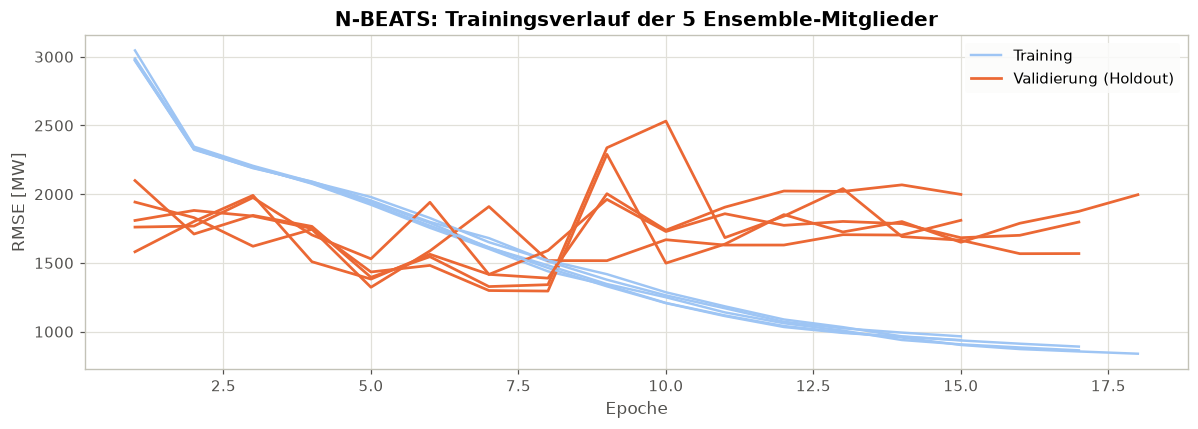

In [8]:
# Visualisierung der Lernkurven (Trainings- und Validierungsfehler je Epoche) 
fig, ax = plt.subplots(figsize=(11, 4))
for i, hist in enumerate(nbeats_histories):
    ep = range(1, len(hist["train"]) + 1)
    # skalierten MSE in RMSE [MW] umrechnen: sqrt(MSE) * sd
    ax.plot(ep, np.sqrt(hist["train"]) * sd, color=FARBEN["Training"], linewidth=1.6,
            label="Training" if i == 0 else None)
    ax.plot(ep, np.sqrt(hist["val"]) * sd, color=FARBEN["Validierung"], linewidth=1.8,
            label="Validierung (Holdout)" if i == 0 else None)
ax.set_xlabel("Epoche")
ax.set_ylabel("RMSE [MW]")
ax.set_title(f"N-BEATS: Trainingsverlauf der {len(ENSEMBLE_SEEDS)} Ensemble-Mitglieder")
ax.legend()
plt.tight_layout()
plt.show()

**Wichtige Punkte zum Trainingsverlauf:**

- **Blau** = Fehler auf den Trainingsdaten, **Orange** = Fehler auf dem Holdout – je Ensemble-Mitglied eine Kurve.
- **Der Trainingsfehler sinkt kontinuierlich, der Validierungsfehler erreicht früh sein Minimum und steigt danach wieder** → klassisches **Overfitting** (das Netz passt sich zunehmend an die Trainingsdaten an, statt zu verallgemeinern).
- **Early Stopping + Checkpointing**: Das Training endet ~10 Epochen nach dem Validierungsminimum und behält den Stand mit dem **niedrigsten Validierungsfehler** (nicht den der letzten Epoche) → die Kurven enden unterschiedlich früh.
- **Die Validierungsfehler streuen stark** trotz identischer Architektur & Daten → sichtbar gemachte **Seed-Varianz**; genau deshalb mitteln wir über ein **Ensemble**.
- **Die Trainingsfehler verlaufen dagegen fast deckungsgleich**: Das Anpassen an die Trainingsdaten gelingt jedem Seed ähnlich gut – das **Verallgemeinern** auf den ungesehenen Zeitraum ist die eigentliche Herausforderung.

### 3.4 Ensemble-Forecast für den Testzeitraum

Der finale Forecast ist der **Mittelwert der Forecasts aller Ensemble-Mitglieder**. Jedes Mitglied prognostiziert aus den letzten `INPUT_SIZE` Stunden der Trainingsreihe in einem Schritt die `HORIZON = 336` Test-Stunden. Das Mitteln gleicht die seed-bedingte Streuung aus – der Ensemble-RMSE liegt typischerweise auf oder unter dem Durchschnitt der Einzel-RMSE.

In [9]:
# Ensemble-Forecast: Mittelwert der Mitglieder-Forecasts
nbeats_pred = np.mean(nbeats_members, axis=0)
nbeats_forecast = pd.Series(nbeats_pred, index=y_test.index, name="N-BEATS")
rmse_nbeats = float(np.sqrt(mean_squared_error(y_test, nbeats_forecast)))

einzel_rmse = [np.sqrt(mean_squared_error(y_test, f)) for f in nbeats_members]
print(f"Einzel-RMSE der Mitglieder : {[round(e) for e in einzel_rmse]}")
print(f"Mittel der Einzel-RMSE      : {np.mean(einzel_rmse):.0f}")      # Mittel der Fehler
print(f"Ensemble N-BEATS RMSE       : {rmse_nbeats:.2f}")               # Fehler des gemittelten Forecasts (Ensemble)

Einzel-RMSE der Mitglieder : [1393, 1638, 2319, 2476, 1421]
Mittel der Einzel-RMSE      : 1849
Ensemble N-BEATS RMSE       : 1715.32


## 4. Vergleich mit den klassischen Modellen

Jetzt der Moment der Wahrheit: Wie schlägt sich das N-BEATS-Ensemble gegen ARIMA, SARIMA und SARIMAX? Alle Modelle werden auf **demselben 14-Tage-Testzeitraum** mit denselben Metriken bewertet:

- **RMSE [MW]** – gleiche Einheit wie die Zielgröße; bestraft große Fehler überproportional
- **MAPE [%]** – relativer Fehler, business-nah interpretierbar („im Schnitt X % daneben“)

In [10]:
# Einheitliche Metriken für alle Modelle:
# - RMSE [MW]  : gleiche Einheit wie die Zielgröße, bestraft große Fehler stärker
# - MAPE [%]   : relativer Fehler, business-nah interpretierbar ("im Schnitt X % daneben")
# Bei diesen Lastdaten ist MAPE stabil, da die Werte nie in Nullnähe liegen.
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    mape = float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100)
    return {"RMSE": rmse, "MAPE [%]": mape}

def metrics_table(y_true, forecasts: dict) -> pd.DataFrame:
    """Baut eine Vergleichstabelle {Modell -> Forecast-Reihe} mit RMSE & MAPE."""
    return pd.DataFrame(
        [{"Modell": name, **compute_metrics(y_true, fc)} for name, fc in forecasts.items()]
    )

# Gemeinsame Wahrheit für alle Vergleiche: die tatsächlichen Testwerte
y_ist = klassische_forecasts["Ist"]

 Modell    RMSE  MAPE [%]
  ARIMA 3017.58     10.95
 SARIMA 2232.70      7.55
SARIMAX 1814.88      5.72
N-BEATS 1715.32      5.94


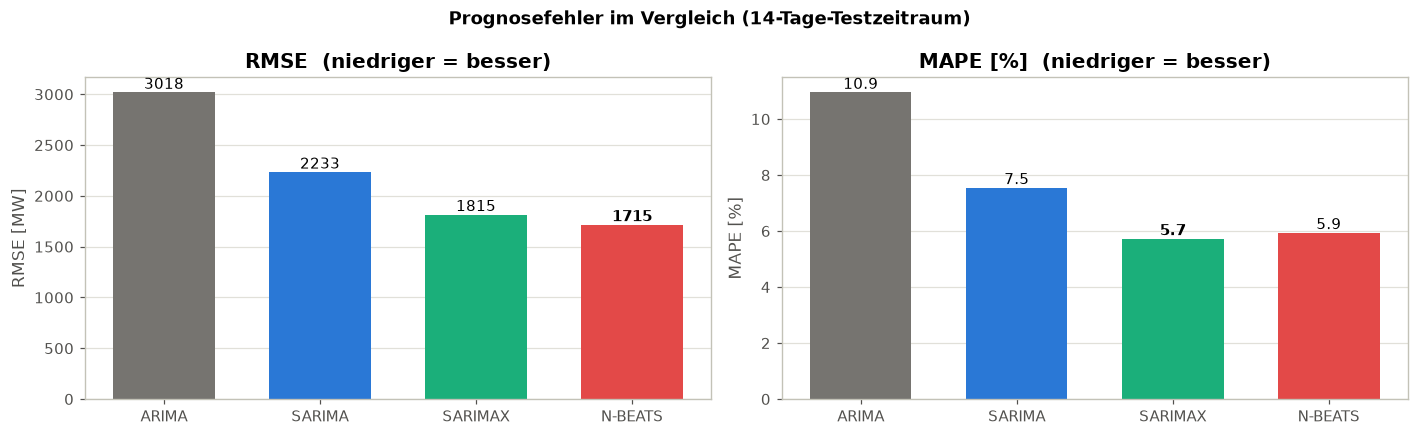

In [11]:
# Metriken für die klassischen Modelle + N-BEATS (einheitlich aus den Forecast-Reihen)
ergebnisse = metrics_table(y_ist, {
    "ARIMA":   klassische_forecasts["ARIMA"],
    "SARIMA":  klassische_forecasts["SARIMA"],
    "SARIMAX": klassische_forecasts["SARIMAX"],
    "N-BEATS": nbeats_forecast,
})
print(ergebnisse.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, metric in zip(axes, ["RMSE", "MAPE [%]"]):
    bars = ax.bar(ergebnisse["Modell"], ergebnisse[metric],
                  color=[FARBEN[m] for m in ergebnisse["Modell"]], width=0.65)
    best = ergebnisse[metric].min()
    for bar, v in zip(bars, ergebnisse[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, v,
                f"{v:.1f}" if "MAPE" in metric else f"{v:.0f}",
                ha="center", va="bottom", fontsize=10,
                fontweight="bold" if v == best else "normal")
    ax.set_title(f"{metric}  (niedriger = besser)")
    ax.grid(False, axis="x")
axes[0].set_ylabel("RMSE [MW]")
axes[1].set_ylabel("MAPE [%]")
fig.suptitle("Prognosefehler im Vergleich (14-Tage-Testzeitraum)", fontweight="bold")
plt.tight_layout()
plt.show()

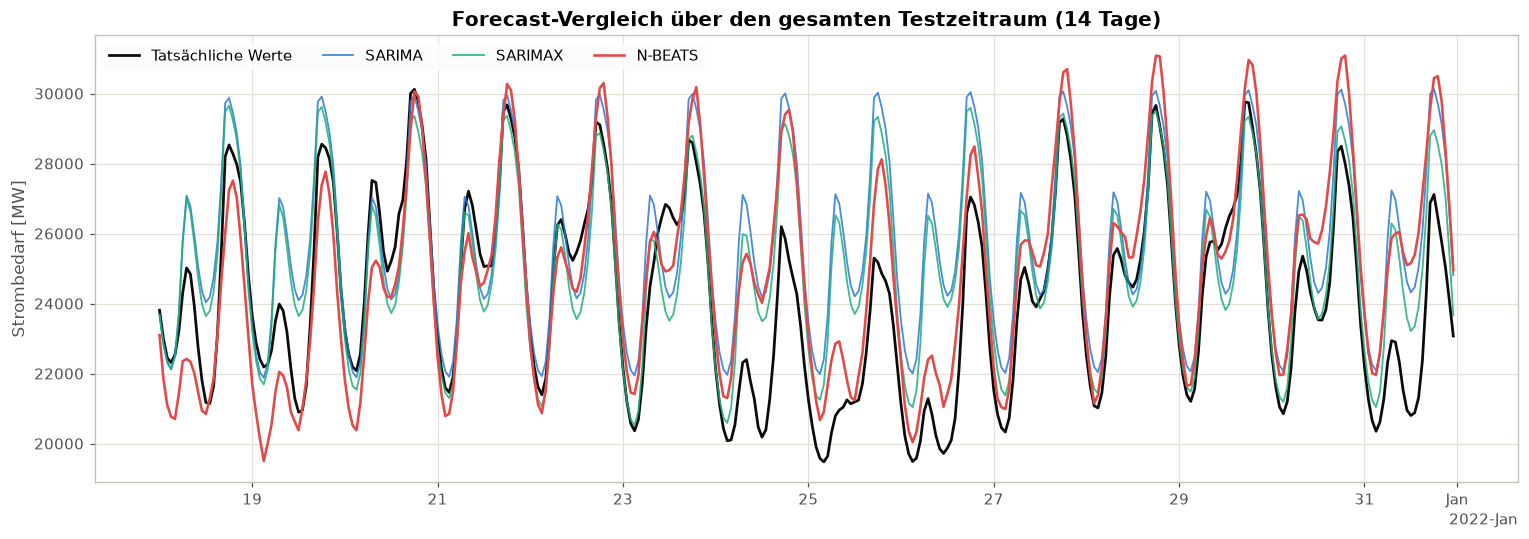

In [12]:
# Overlay-Plot: tatsächliche Werte vs. SARIMA, SARIMAX und N-BEATS
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(klassische_forecasts.index, klassische_forecasts["Ist"],
        label="Tatsächliche Werte", color=FARBEN["Ist"], linewidth=1.8)
ax.plot(klassische_forecasts.index, klassische_forecasts["SARIMA"],
        label="SARIMA", color=FARBEN["SARIMA"], linewidth=1.2, alpha=0.85)
ax.plot(klassische_forecasts.index, klassische_forecasts["SARIMAX"],
        label="SARIMAX", color=FARBEN["SARIMAX"], linewidth=1.2, alpha=0.85)
ax.plot(nbeats_forecast.index, nbeats_forecast,
        label="N-BEATS", color=FARBEN["N-BEATS"], linewidth=1.7)
ax.set_title("Forecast-Vergleich über den gesamten Testzeitraum (14 Tage)")
ax.set_ylabel("Strombedarf [MW]")
datum_achse(ax)
ax.legend(loc="upper left", ncols=4)
plt.tight_layout()
plt.show()

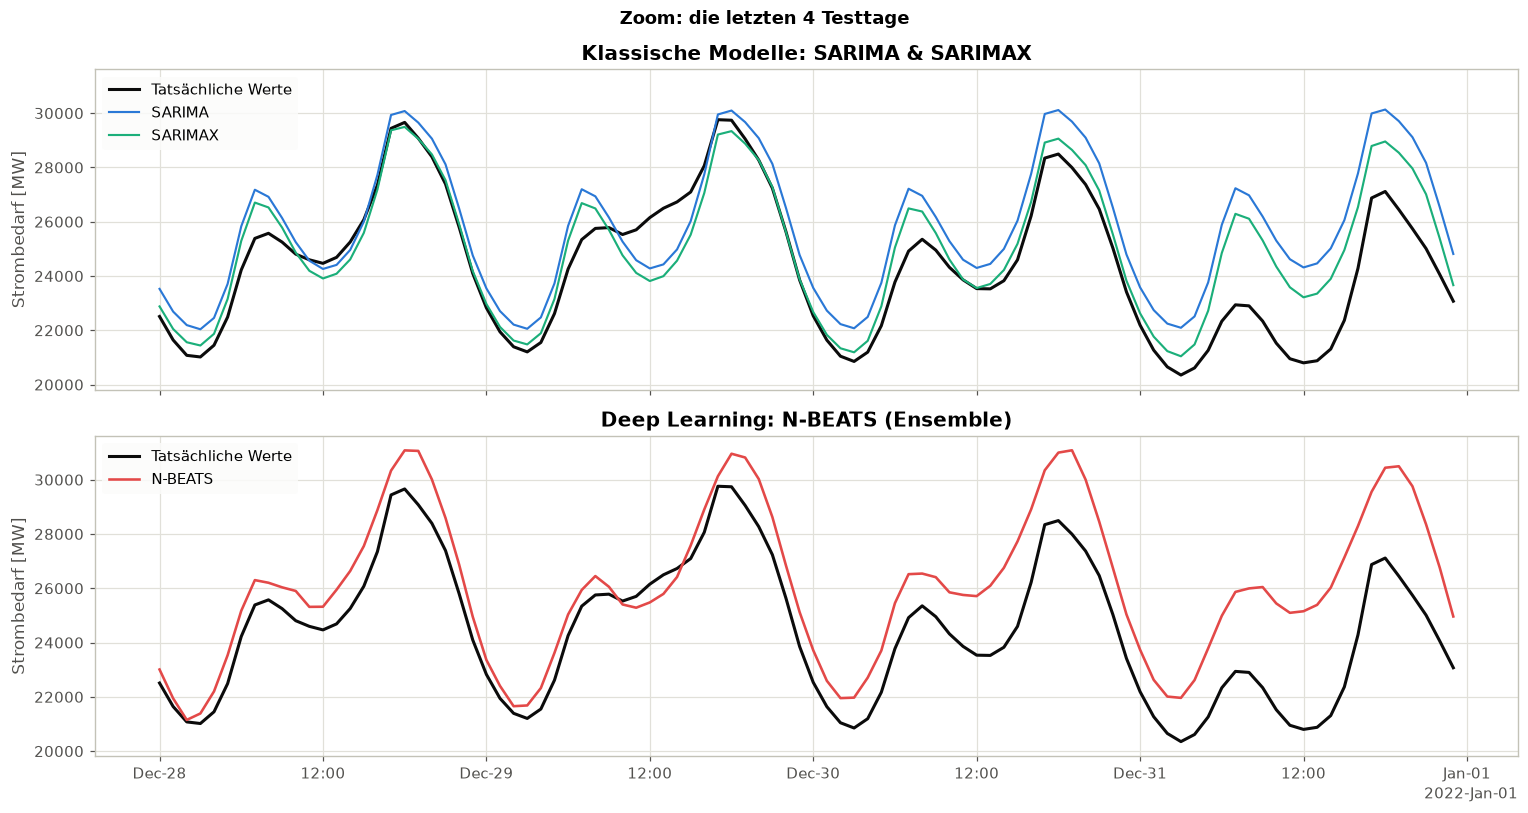

In [13]:
# Zoom auf die letzten 4 Tage – zwei Panels für bessere Lesbarkeit:
# oben die klassischen Modelle, unten N-BEATS (jeweils gegen die Ist-Werte)
zoom = nbeats_forecast.index[-24 * 4:]
fig, axes = plt.subplots(2, 1, figsize=(14, 7.5), sharex=True, sharey=True)

for ax in axes:
    ax.plot(zoom, klassische_forecasts.loc[zoom, "Ist"],
            label="Tatsächliche Werte", color=FARBEN["Ist"], linewidth=2)
    ax.set_ylabel("Strombedarf [MW]")

axes[0].plot(zoom, klassische_forecasts.loc[zoom, "SARIMA"],
             label="SARIMA", color=FARBEN["SARIMA"], linewidth=1.4)
axes[0].plot(zoom, klassische_forecasts.loc[zoom, "SARIMAX"],
             label="SARIMAX", color=FARBEN["SARIMAX"], linewidth=1.4)
axes[0].set_title("Klassische Modelle: SARIMA & SARIMAX")

axes[1].plot(zoom, nbeats_forecast.loc[zoom],
             label="N-BEATS", color=FARBEN["N-BEATS"], linewidth=1.7)
axes[1].set_title("Deep Learning: N-BEATS (Ensemble)")

for ax in axes:
    ax.legend(loc="upper left")
datum_achse(axes[1])
fig.suptitle("Zoom: die letzten 4 Testtage", fontweight="bold")
plt.tight_layout()
plt.show()

### Zwischenfazit: N-BEATS (univariat)

- **Fairer Vergleichspartner ist SARIMA** (beide nutzen nur die Vergangenheit der Zielreihe): N-BEATS übertrifft SARIMA deutlich – **ohne** manuelle Stationaritäts- oder Saisonalitätsanalyse.
- Es erreicht damit ungefähr das Niveau von SARIMAX, obwohl dieses zusätzlich exogene Variablen nutzt.
- **RMSE und MAPE bewerten unterschiedlich:** RMSE wird von wenigen großen Ausreißern dominiert, MAPE bildet den typischen relativen Fehler ab. → SARIMAX ist im Schnitt präziser, leistet sich aber die gröberen Fehlschüsse.
- **Ein einzelner Trainingslauf ist nicht belastbar** (starke Seed-Streuung) – erst das **Ensemble** liefert einen stabilen, reproduzierbaren Wert.

----

## 5. Erweiterung: N-BEATSx (mit exogenen Variablen)

N-BEATS ist rein univariat. Die Erweiterung **N-BEATSx** (Olivares et al., 2023) ergänzt das Modell um **exogene Variablen**.

**Idee:** Jeder Block bekommt als Eingabe nicht nur das Rückblickfenster der Zielreihe, sondern zusätzlich die **zukünftigen Werte** der exogenen Variablen im Forecast-Horizont (hier: Temperatur, Windgeschwindigkeit, PV-Produktion, Windproduktion). Konkret:

- Das Rückblickfenster der Zielreihe hat die Form `[INPUT_SIZE]` → 336 Werte
- Die zukünftigen exogenen Werte haben die Form `[HORIZON, n_exog]` → 336 × 4 = 1344 Werte
- Diese Matrix wird zu einem 1D-Vektor **(„flachgemacht", `.flatten()`)** und direkt hinter das Rückblickfenster angehängt
- Der FC-Stack bekommt damit einen einzigen Eingabevektor der Länge **1680** (statt 336 bei N-BEATS)

Damit spiegelt N-BEATSx genau denselben Informationsstand wie SARIMAX wider: Beide nutzen die tatsächlich beobachteten exogenen Werte im Testzeitraum – in der Praxis müssten diese z.B. durch Wetterprognosen bereitgestellt werden.

> **Architekturunterschiede zu N-BEATS:**
> - Eingabedimension: `INPUT_SIZE + HORIZON × n_exog` statt nur `INPUT_SIZE`
> - Backcast bezieht sich weiterhin nur auf das Zielreihen-Rückblickfenster
> - Ansonsten identisch: FC-Stack, lineare Projektionen, Doubly-Residual-Stacking

### 5.1 Datenaufbereitung: Exogene Variablen skalieren & Fenster erstellen

Die exogenen Variablen werden **standardisiert** (Fit nur auf Trainingsdaten). Für jedes Sliding Window gehört zum Zielreihen-Rückblick ($L$ Stunden) der dazugehörige exogene Block der **folgenden** $H$ Stunden – genau die Werte, die das Modell als Zusatzinfo für den Forecast bekommt.

In [14]:
exog_vars = split_config["exog_vars_reduced"]
n_exog = len(exog_vars)

exog_all   = data_hourly[exog_vars].astype("float32")
exog_train = exog_all.iloc[:-test_size]
exog_test  = exog_all.iloc[-test_size:]

scaler_x = StandardScaler()
exog_train_sc = scaler_x.fit_transform(exog_train).astype("float32")
exog_test_sc  = scaler_x.transform(exog_test).astype("float32")

def make_windows_x(y_arr, x_arr, input_size, horizon, stride=1):
    """Fenster für N-BEATSx: Zielreihen-Rückblick + zukünftige exogene Variablen.

    stride: Schrittweite zwischen aufeinanderfolgenden Fenstern (1 = jede Stunde)."""
    Y_in, X_fut, Y_out = [], [], []
    for i in range(0, len(y_arr) - input_size - horizon + 1, stride):
        Y_in.append(y_arr[i:i + input_size])
        X_fut.append(x_arr[i + input_size:i + input_size + horizon].flatten())
        Y_out.append(y_arr[i + input_size:i + input_size + horizon])
    return (np.asarray(Y_in,  dtype="float32"),
            np.asarray(X_fut, dtype="float32"),
            np.asarray(Y_out, dtype="float32"))

# Temporale Holdout-Validierung: letzter HORIZON-Block der Trainingsreihe
# Trainingsfenster enden alle vor dem Holdout (kein Leakage)
exog_for_windows = exog_train_sc[:-HORIZON]
Yx_all, Xf_all, Yy_all = make_windows_x(train_for_windows, exog_for_windows, INPUT_SIZE, HORIZON, STRIDE)

# Validierungsfenster: Kontext + exogene Werte *während* des Holdouts
val_ctx_x_t    = torch.from_numpy(train_scaled[-(INPUT_SIZE + HORIZON):-HORIZON]).unsqueeze(0).to(device)
val_exog_fut_t = torch.from_numpy(exog_train_sc[-HORIZON:].flatten()[np.newaxis, :]).to(device)
val_tgt_x_t    = torch.from_numpy(train_scaled[-HORIZON:]).unsqueeze(0).to(device)

train_loader_x = DataLoader(
    TensorDataset(torch.from_numpy(Yx_all),
                  torch.from_numpy(Xf_all),
                  torch.from_numpy(Yy_all)),
    batch_size=512, shuffle=True, drop_last=False,
)

print(f"Exogene Variablen ({n_exog}): {exog_vars}")
print(f"Eingabedimension N-BEATSx: {INPUT_SIZE} (Ziel) + {HORIZON}×{n_exog} (Exog) = {INPUT_SIZE + HORIZON * n_exog}")
print(f"Trainingsfenster: {len(Yx_all)}")
print(f"Holdout-Validierung: letzter {HORIZON}h-Block der Trainingsreihe")

Exogene Variablen (4): ['Temperature', 'Wind_speed', 'PV_production', 'Wind_production']
Eingabedimension N-BEATSx: 336 (Ziel) + 336×4 (Exog) = 1680
Trainingsfenster: 24961
Holdout-Validierung: letzter 336h-Block der Trainingsreihe


### 5.2 N-BEATSx-Modell

Die Architektur ist identisch zu N-BEATS – mit einem Unterschied: `NBeatsXBlock` erwartet als Eingabe die Konkatenation aus Zielreihen-Rückblick und zukünftigen exogenen Werten. Der Backcast rekonstruiert weiterhin nur das Zielreihen-Rückblickfenster.

In [15]:
class NBeatsXBlock(nn.Module):
    """N-BEATSx-Block: Zielreihen-Rückblick + zukünftige Exog-Werte als Eingabe."""
    def __init__(self, input_size, horizon, n_exog, hidden=256, n_layers=4):
        super().__init__()
        # ►►► WESENTLICHER UNTERSCHIED ZU N-BEATS ◄◄◄
        # Der FC-Stack bekommt zusätzlich die zukünftigen exogenen Werte. Eingabelänge daher
        # input_size + horizon*n_exog (bei N-BEATS war es nur input_size).
        total_input = input_size + horizon * n_exog   # [y_lookback | x_future_flat]
        layers = [nn.Linear(total_input, hidden), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        self.fc = nn.Sequential(*layers)
        # Köpfe unverändert: der Backcast rekonstruiert weiterhin NUR die Zielreihe (input_size),
        # NICHT die exogenen Werte – die sind reine Zusatz-Eingabe, kein Rekonstruktionsziel.
        self.backcast = nn.Linear(hidden, input_size)  # rekonstruiert nur Zielreihe
        self.forecast = nn.Linear(hidden, horizon)     # Forecast wie bei N-BEATS

    def forward(self, y_in, x_fut):
        # ►►► UNTERSCHIED: Zielreihen-Rückblick (y_in) und zukünftige Exog-Werte (x_fut) werden
        #     zu EINEM Eingabevektor zusammengehängt (torch.cat), bevor sie in den FC-Stack gehen.
        h = self.fc(torch.cat([y_in, x_fut], dim=-1))
        return self.backcast(h), self.forecast(h)


class NBeatsX(nn.Module):
    """N-BEATSx: Doubly-Residual-Stacking mit exogenen Variablen."""
    def __init__(self, input_size, horizon, n_exog,
                 hidden=256, n_stacks=3, n_blocks=2, n_layers=4):
        super().__init__()
        self.horizon = horizon
        # Aufbau identisch zu N-BEATS – nur die Blöcke sind NBeatsXBlock (mit Exog-Eingang).
        self.blocks = nn.ModuleList([
            NBeatsXBlock(input_size, horizon, n_exog, hidden, n_layers)
            for _ in range(n_stacks * n_blocks)
        ])

    def forward(self, y_in, x_fut):
        # Doubly-Residual-Stacking wie bei N-BEATS, ABER mit zwei Feinheiten:
        # - das Residuum betrifft weiterhin NUR die Zielreihe (nur y_in wird Block für Block kleiner)
        # - x_fut (Exog) wird JEDEM Block unverändert mitgegeben – es wird nicht "wegerklärt"
        residual = y_in
        forecast = y_in.new_zeros(y_in.size(0), self.horizon)
        for block in self.blocks:
            backcast, block_forecast = block(residual, x_fut)   # x_fut an jeden Block
            residual = residual - backcast        # nur die Zielreihe wird reduziert
            forecast = forecast + block_forecast
        return forecast


model_x = NBeatsX(INPUT_SIZE, HORIZON, n_exog, hidden=256, n_stacks=3, n_blocks=2).to(device)
n_params_x = sum(p.numel() for p in model_x.parameters())
print(f"N-BEATSx | Eingabedimension pro Block: {INPUT_SIZE + HORIZON * n_exog}")
print(f"Trainierbare Parameter: {n_params_x:,}  (N-BEATS hatte {n_params:,})")

N-BEATSx | Eingabedimension pro Block: 1680
Trainierbare Parameter: 4,802,496  (N-BEATS hatte 2,738,112)


### 5.3 Training & Ensemble-Forecast

Identisches Setup wie bei N-BEATS: **Seed-Ensemble** (dieselben Seeds), Early Stopping, LR-Scheduling und Holdout-Validierung. Wir verwenden dieselbe Trainingsfunktion `train_one(...)` – nur die Adapter für Batch-Format und Validierung unterscheiden sich, weil N-BEATSx zusätzlich die exogenen Variablen verarbeitet.

Seed   42 | Epochen 27 | beste Val-MSE 0.0890 | RMSE 1305
Seed    1 | Epochen 21 | beste Val-MSE 0.0937 | RMSE 1528
Seed    7 | Epochen 17 | beste Val-MSE 0.0962 | RMSE 1632
Seed   13 | Epochen 16 | beste Val-MSE 0.1199 | RMSE 1572
Seed   99 | Epochen 19 | beste Val-MSE 0.0768 | RMSE 1495

5 Modelle trainiert in 38.1s


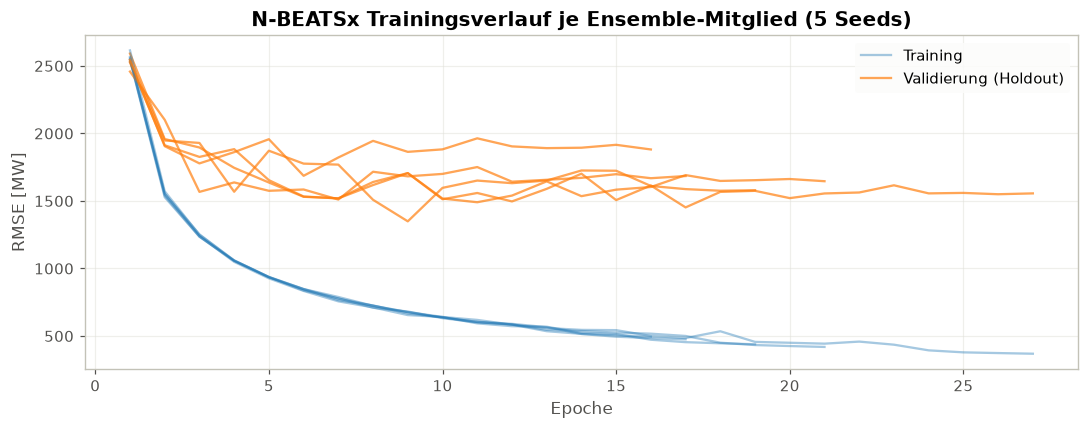

Einzel-RMSE der Mitglieder : [1305, 1528, 1632, 1572, 1495]
Ensemble N-BEATSx RMSE     : 1417.96  (N-BEATS Ensemble: 1715.32)


In [16]:
# Adapter für N-BEATSx: Batch enthält zusätzlich die exogenen Variablen
def forward_nbeatsx(model, batch):
    yb, xb, tb = batch
    return model(yb, xb), tb

val_nbeatsx = lambda m: nn.functional.mse_loss(
    m(val_ctx_x_t, val_exog_fut_t), val_tgt_x_t).item()

last_y  = torch.from_numpy(train_scaled[-INPUT_SIZE:]).unsqueeze(0).to(device)
x_fut_t = torch.from_numpy(exog_test_sc.flatten()[np.newaxis, :]).to(device)

# ── Ensemble trainieren ───────────────────────────────────────────────────────
nbeatsx_members, nbeatsx_histories = [], []
t0 = time.time()
for s in ENSEMBLE_SEEDS:
    torch.manual_seed(s)
    member = NBeatsX(INPUT_SIZE, HORIZON, n_exog, hidden=256, n_stacks=3, n_blocks=2).to(device)
    member, hist, best = train_one(member, train_loader_x, forward_nbeatsx, val_nbeatsx, seed=s)

    member.eval()
    with torch.no_grad():
        fc = member(last_y, x_fut_t).squeeze(0).cpu().numpy() * sd + mu
    nbeatsx_members.append(fc)
    nbeatsx_histories.append(hist)
    rmse_i = np.sqrt(mean_squared_error(y_test, fc))
    print(f"Seed {s:>4} | Epochen {len(hist['train']):>2} | beste Val-MSE {best:.4f} | RMSE {rmse_i:.0f}")

print(f"\n{len(ENSEMBLE_SEEDS)} Modelle trainiert in {time.time()-t0:.1f}s")

# ── Trainingsverlauf je Mitglied ──────────────────────────────────────────────
plt.figure(figsize=(10, 4))
for i, hist in enumerate(nbeatsx_histories):
    ep = range(1, len(hist["train"]) + 1)
    # skalierten MSE in RMSE [MW] umrechnen: sqrt(MSE) * sd
    plt.plot(ep, np.sqrt(hist["train"]) * sd, color="tab:blue", alpha=0.4,
             label="Training" if i == 0 else None)
    plt.plot(ep, np.sqrt(hist["val"]) * sd, color="tab:orange", alpha=0.7,
             label="Validierung (Holdout)" if i == 0 else None)
plt.xlabel("Epoche")
plt.ylabel("RMSE [MW]")
plt.title(f"N-BEATSx Trainingsverlauf je Ensemble-Mitglied ({len(ENSEMBLE_SEEDS)} Seeds)")
plt.grid(True, alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ── Ensemble-Forecast ─────────────────────────────────────────────────────────
nbeatsx_pred = np.mean(nbeatsx_members, axis=0)
nbeatsx_forecast = pd.Series(nbeatsx_pred, index=y_test.index, name="N-BEATSx")
rmse_nbeatsx = float(np.sqrt(mean_squared_error(y_test, nbeatsx_forecast)))

einzel_rmse_x = [np.sqrt(mean_squared_error(y_test, f)) for f in nbeatsx_members]
print(f"Einzel-RMSE der Mitglieder : {[round(e) for e in einzel_rmse_x]}")
print(f"Ensemble N-BEATSx RMSE     : {rmse_nbeatsx:.2f}  (N-BEATS Ensemble: {rmse_nbeats:.2f})")

### 5.4 Gesamtvergleich: alle 5 Modelle

Damit stehen alle fünf Modelle auf demselben Testzeitraum nebeneinander – von der einfachsten Baseline (ARIMA) bis zum Deep-Learning-Modell mit exogenen Variablen (N-BEATSx).

  Modell    RMSE  MAPE [%]
   ARIMA 3017.58     10.95
  SARIMA 2232.70      7.55
 SARIMAX 1814.88      5.72
 N-BEATS 1715.32      5.94
N-BEATSx 1417.96      4.74


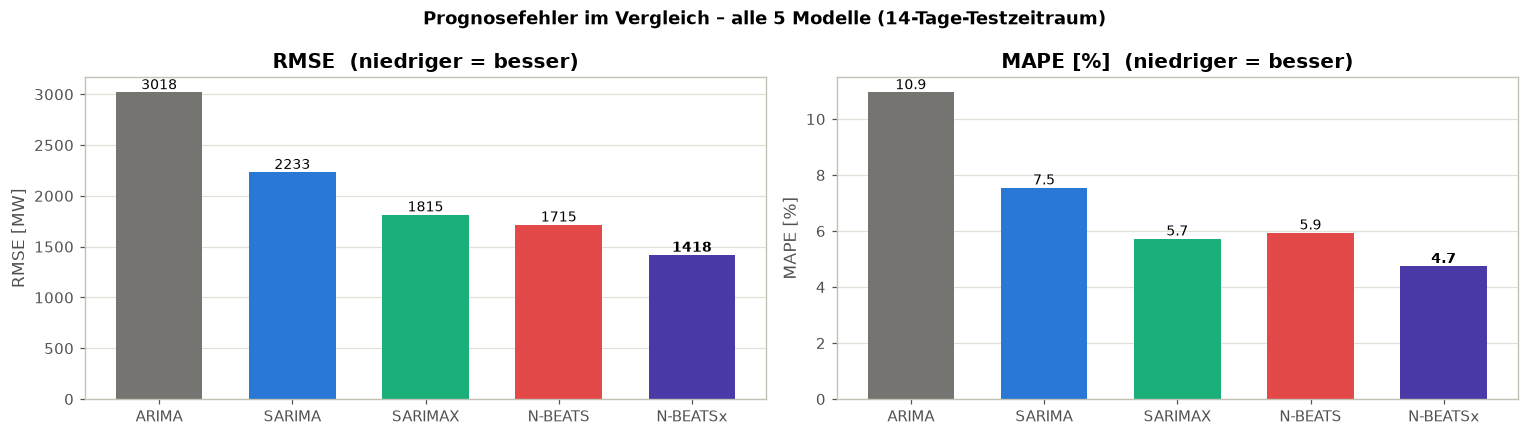

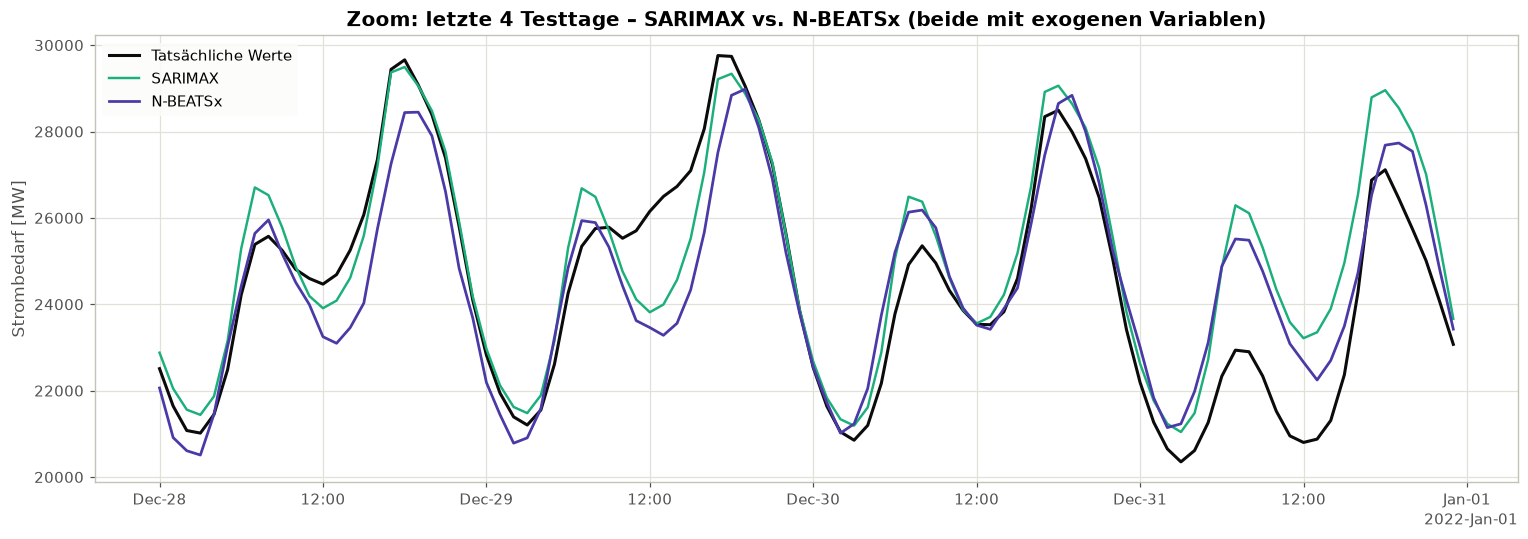

In [17]:
alle = metrics_table(y_ist, {
    "ARIMA":    klassische_forecasts["ARIMA"],
    "SARIMA":   klassische_forecasts["SARIMA"],
    "SARIMAX":  klassische_forecasts["SARIMAX"],
    "N-BEATS":  nbeats_forecast,
    "N-BEATSx": nbeatsx_forecast,
})
print(alle.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, metric in zip(axes, ["RMSE", "MAPE [%]"]):
    bars = ax.bar(alle["Modell"], alle[metric],
                  color=[FARBEN[m] for m in alle["Modell"]], width=0.65)
    best = alle[metric].min()
    for bar, v in zip(bars, alle[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, v,
                f"{v:.1f}" if "MAPE" in metric else f"{v:.0f}",
                ha="center", va="bottom", fontsize=9,
                fontweight="bold" if v == best else "normal")
    ax.set_title(f"{metric}  (niedriger = besser)")
    ax.grid(False, axis="x")
axes[0].set_ylabel("RMSE [MW]")
axes[1].set_ylabel("MAPE [%]")
fig.suptitle("Prognosefehler im Vergleich – alle 5 Modelle (14-Tage-Testzeitraum)", fontweight="bold")
plt.tight_layout()
plt.show()

# Zoom auf die letzten 4 Tage – nur das exogene Paar SARIMAX vs. N-BEATSx
zoom = nbeatsx_forecast.index[-24 * 4:]
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(zoom, y_ist.loc[zoom], label="Tatsächliche Werte", color=FARBEN["Ist"], linewidth=2)
ax.plot(zoom, klassische_forecasts.loc[zoom, "SARIMAX"],
        label="SARIMAX", color=FARBEN["SARIMAX"], linewidth=1.6)
ax.plot(zoom, nbeatsx_forecast.loc[zoom],
        label="N-BEATSx", color=FARBEN["N-BEATSx"], linewidth=1.8)
ax.set_title("Zoom: letzte 4 Testtage – SARIMAX vs. N-BEATSx (beide mit exogenen Variablen)")
ax.set_ylabel("Strombedarf [MW]")
datum_achse(ax)
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()


### 5.5 Interpretation & Fazit N-BEATSx

- **Exogene Variablen helfen deutlich:** N-BEATSx schlägt N-BEATS klar – genau wie SARIMAX gegenüber SARIMA.
- **N-BEATSx ist das beste Modell** und unterbietet SARIMAX: gleicher Informationsstand, aber es bildet **nichtlineare** Zusammenhänge (z.B. Temperatur ↔ Last) flexibler ab als das lineare SARIMAX.
- **Das Ensemble bleibt nötig:** Die exogenen Variablen verbessern die Prognose, beseitigen die Seed-Streuung aber nicht.

> 💡 **Praxishinweis:** Die exogenen Werte müssen für den Forecast-Horizont **im Voraus bekannt** sein (wie bei SARIMAX) – in der Praxis z.B. aus Wetterprognosen.

### 5.6 Residuenvergleich: SARIMAX vs. N-BEATSx


| Diagnose | Fragestellung |
|---|---|
| **Zeitverlauf & Verteilung** | Gibt es systematische Fehler (Bias)? Wie groß ist die Streuung? |
| **Fehler nach Tagesstunde** | Verfehlt ein Modell gezielt die Tages-Peaks/-Täler? |
| **ACF der Residuen** | Bleibt zeitliche Struktur (Autokorrelation) übrig? Ein ideales Modell hinterlässt strukturloses „weißes Rauschen“ (vgl. White-Noise-Check im klassischen Notebook). |

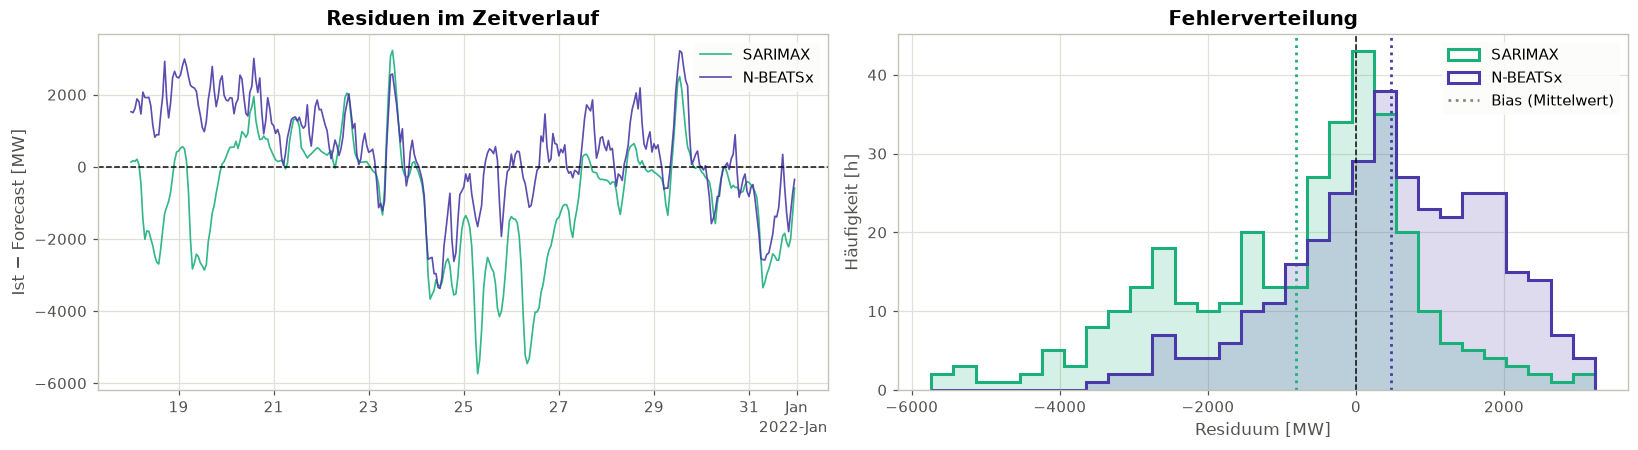

                   SARIMAX  N-BEATSx
Bias (Mittelwert)   -815.4     467.5
Streuung (Std)      1623.8    1340.7
MAE                 1319.9    1149.3


In [18]:
# Test-Residuen (Ist - Forecast); .values, um versehentlichen Index-Abgleich zu vermeiden
resid_sarimax = pd.Series(y_ist.values - klassische_forecasts["SARIMAX"].values, index=y_ist.index)
resid_nbeatsx = pd.Series(y_ist.values - nbeatsx_forecast.values,                index=y_ist.index)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))

# (a) Residuen im Zeitverlauf
axes[0].plot(resid_sarimax.index, resid_sarimax, label="SARIMAX",
             color=FARBEN["SARIMAX"], linewidth=1.1, alpha=0.9)
axes[0].plot(resid_nbeatsx.index, resid_nbeatsx, label="N-BEATSx",
             color=FARBEN["N-BEATSx"], linewidth=1.1, alpha=0.9)
axes[0].axhline(0, color=FARBEN["Ist"], linestyle="--", linewidth=1)
axes[0].set_title("Residuen im Zeitverlauf")
axes[0].set_ylabel("Ist − Forecast [MW]")
datum_achse(axes[0])
axes[0].legend()

# (b) Fehlerverteilung
# Gemeinsame Bins fuer beide Modelle -> die Balken sind deckungsgleich und vergleichbar
bins = np.linspace(min(resid_sarimax.min(), resid_nbeatsx.min()),
                   max(resid_sarimax.max(), resid_nbeatsx.max()), 31)
for name, resid in (("SARIMAX", resid_sarimax), ("N-BEATSx", resid_nbeatsx)):
    # helle Fuellung + kraeftige Kontur: beide Verteilungen bleiben im Overlap unterscheidbar
    axes[1].hist(resid, bins=bins, histtype="stepfilled", alpha=0.18, color=FARBEN[name])
    axes[1].hist(resid, bins=bins, histtype="step", linewidth=2.0, color=FARBEN[name], label=name)
    axes[1].axvline(resid.mean(), color=FARBEN[name], linestyle=":", linewidth=1.8)  # Bias
axes[1].axvline(0, color=FARBEN["Ist"], linestyle="--", linewidth=1)
axes[1].set_title("Fehlerverteilung")
axes[1].set_xlabel("Residuum [MW]")
axes[1].set_ylabel("Häufigkeit [h]")
handles, labels = axes[1].get_legend_handles_labels()
handles.append(Line2D([], [], color="#898781", linestyle=":", linewidth=1.8))
labels.append("Bias (Mittelwert)")
axes[1].legend(handles, labels)
plt.tight_layout()
plt.show()

# Kurzkennzahlen der Residuen
resid_stats = pd.DataFrame({
    "SARIMAX":  [resid_sarimax.mean(), resid_sarimax.std(), resid_sarimax.abs().mean()],
    "N-BEATSx": [resid_nbeatsx.mean(), resid_nbeatsx.std(), resid_nbeatsx.abs().mean()],
}, index=["Bias (Mittelwert)", "Streuung (Std)", "MAE"]).round(1)
print(resid_stats.to_string())

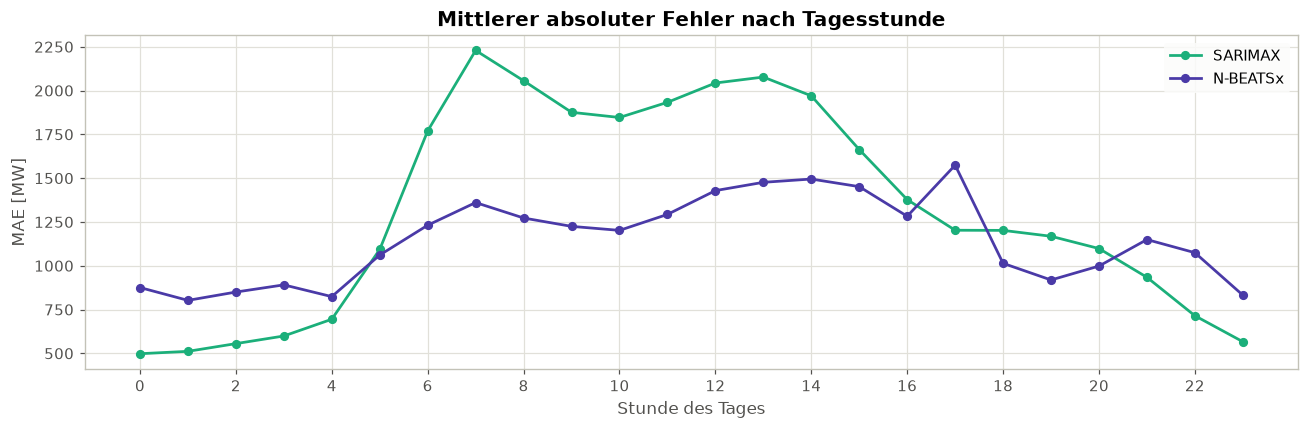

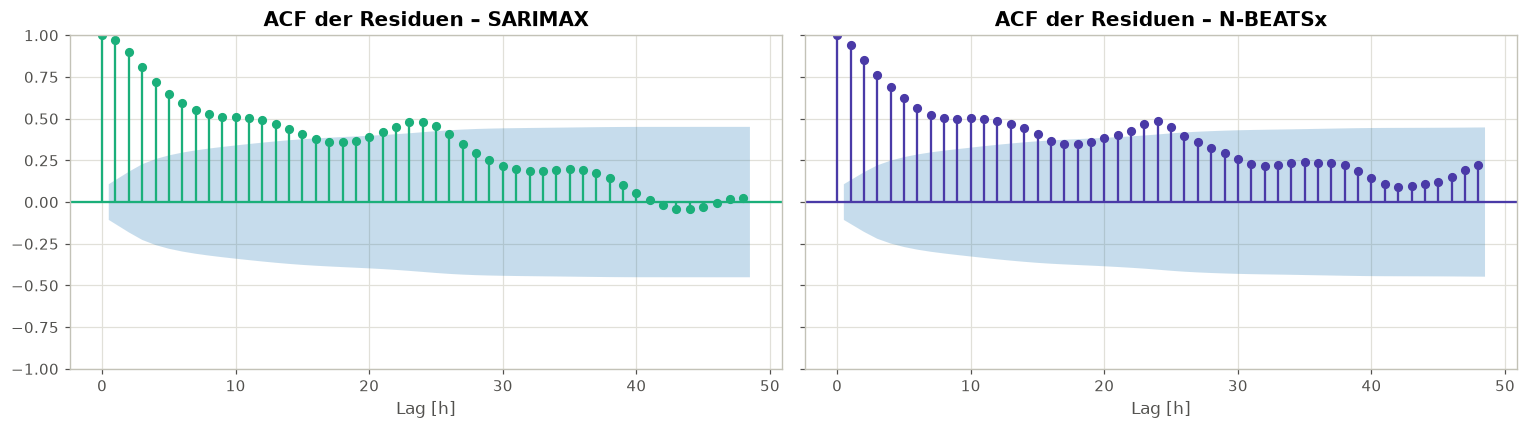

In [19]:
# Mittlerer absoluter Fehler nach Tagesstunde: verfehlt ein Modell gezielt bestimmte Stunden?
mae_by_hour = pd.DataFrame(
    {"SARIMAX": resid_sarimax.abs().values, "N-BEATSx": resid_nbeatsx.abs().values},
    index=resid_sarimax.index.hour,
).groupby(level=0).mean()

fig, ax = plt.subplots(figsize=(12, 4))
for name in ["SARIMAX", "N-BEATSx"]:
    ax.plot(mae_by_hour.index, mae_by_hour[name], marker="o", markersize=5,
            label=name, color=FARBEN[name], linewidth=1.8)
ax.set_title("Mittlerer absoluter Fehler nach Tagesstunde")
ax.set_xlabel("Stunde des Tages")
ax.set_ylabel("MAE [MW]")
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.tight_layout()
plt.show()

# ACF der Residuen: bleibt zeitliche Struktur übrig? (flach ≈ weißes Rauschen)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
plot_acf(resid_sarimax, lags=48, ax=axes[0], color=FARBEN["SARIMAX"],
         vlines_kwargs={"colors": FARBEN["SARIMAX"]})
axes[0].set_title("ACF der Residuen – SARIMAX")
plot_acf(resid_nbeatsx, lags=48, ax=axes[1], color=FARBEN["N-BEATSx"],
         vlines_kwargs={"colors": FARBEN["N-BEATSx"]})
axes[1].set_title("ACF der Residuen – N-BEATSx")
for ax in axes:
    ax.set_xlabel("Lag [h]")
plt.tight_layout()
plt.show()

**Auswertung Residuen-Vergleich:**

- **Residuen im Zeitverlauf:** Fehler schwanken nicht zufällig um null. \
SARIMAX liegt überwiegend **unter** der Nulllinie (**überschätzt** die Last), N-BEATSx überwiegend **darüber** (**unterschätzt** sie). SARIMAX' Fehler wachsen in der **Feiertagswoche** deutlich an: Es kann den weihnachtlichen Lastrückgang nicht antizipieren.
- **Fehlerverteilung:** Bestätigt diesen systematischen **Bias**. N-BEATSx streut zudem **enger** und hat den kleineren mittleren absoluten Fehler.
- **Fehler nach Tagesstunde:** SARIMAX ist nachts sehr präzise, verfehlt aber **Morgenrampe und Mittagsspitze** deutlich. N-BEATSx zeigt ein **flacheres Profil**, nachts etwas schlechter, tagsüber klar besser. \
→ SARIMAX bündelt seine großen Fehler auf wenige Stunden (das treibt den RMSE), N-BEATSx verteilt sie gleichmäßiger.
- **ACF der Residuen:** Beide Reihen bleiben **deutlich autokorreliert**, mit einem klaren Buckel bei **Lag 24** (Tagesrhythmus). \
Kein Modell hinterlässt „weißes Rauschen“ – es bleibt zeitliche Struktur ungenutzt, die ein stärkeres Modell noch einfangen könnte.

**Fazit:** N-BEATSx ist insgesamt präziser (engere Streuung, kleinerer MAE), aber **beide** Modelle zeigen einen systematischen Bias und lassen Tagesstruktur im Residuum zurück.

<br>

----

## 6. Erweiterung: Interpretable N-BEATS (zerlegbarer Forecast)

Bisher haben wir die **generische** Variante genutzt (frei lernbare lineare Projektionen). N-BEATS gibt es aber auch in einer **interpretierbaren** Variante, die den Forecast in verständliche Komponenten zerlegt.

**Idee:** Statt freier Projektionen bekommt jeder Block **feste Basisfunktionen**, deren Gewichte (`theta`) gelernt werden:

| Stack | Basis | bildet ab |
|---|---|---|
| **Trend-Stack** | Polynome $1, t, t^2, \dots$ | langsame, glatte Verläufe |
| **Saison-Stack** | Fourier-Terme $\cos(2\pi k t), \sin(2\pi k t)$ | periodische Muster |

Bei unserem 336-h-Horizont entspricht die Harmonische $k=2$ etwa dem **Wochen-** und $k=14$ dem **Tagesrhythmus**. Weil die Tageslast **nicht sinusförmig** ist, braucht es auch deren Oberschwingungen ($k=28, 42, \dots$) – wir nutzen **96 Harmonische** ($K=48$ ist zu grob, $K=168$ überfittet).

**Weight-Sharing:** Anders als bei generic **teilen sich die Blöcke innerhalb eines Stacks die Gewichte** – derselbe Block wird mehrfach auf das jeweilige Residuum angewandt. Diese starke Regularisierung ist der Schlüssel, damit die interpretierbare Variante stabil bleibt.

Durch das Doubly-Residual-Stacking erklärt der **Trend-Stack zuerst** den glatten Anteil, der **Saison-Stack** anschließend den periodischen Rest. Der Gesamt-Forecast ist die Summe – und lässt sich in **Trend + Saison zerlegen und getrennt darstellen**.

> ⚖️ **Einordnung:** Interpretable N-BEATS ist – wie generic N-BEATS – **univariat** (keine exogenen Variablen). Fairer Partner ist daher **generic N-BEATS / SARIMA**, nicht N-BEATSx. Der Mehrwert ist die **Interpretierbarkeit** der Zerlegung; exogene Effekte fängt weiterhin nur N-BEATSx.

In [20]:
# Interpretable N-BEATS: feste Basisfunktionen statt frei lernbarer Projektionen.
#
# ►►► DREI UNTERSCHIEDE ZU GENERIC N-BEATS ◄◄◄
#  1) Die Basis-Klassen unten sind NEU - generic N-BEATS hat keine Basisfunktionen.
#  2) Ein Block gibt nicht direkt die Zeitreihe aus, sondern wenige theta-Koeffizienten,
#     die auf eine FESTE Basis (Polynom bzw. Fourier) projiziert werden.
#  3) Statt 6 unabhaengiger Bloecke gibt es 2 Bloecke mit FESTER ROLLE (Trend, Saison),
#     die ihre Gewichte teilen (Weight-Sharing).

class TrendBasis(nn.Module):
    """Polynom-Basis (Trend): Zeilen t^0, t^1, ..., t^degree."""
    def __init__(self, degree, backcast_size, forecast_size):
        super().__init__()
        t_b = np.arange(backcast_size, dtype=np.float32) / backcast_size
        t_f = np.arange(forecast_size, dtype=np.float32) / forecast_size
        # ►►► NEU: register_buffer => feste Matrix, die NICHT trainiert wird
        #     (anders als die frei lernbaren nn.Linear-Gewichte bei generic N-BEATS)
        self.register_buffer("Bb", torch.tensor(np.stack([t_b ** i for i in range(degree + 1)])))
        self.register_buffer("Bf", torch.tensor(np.stack([t_f ** i for i in range(degree + 1)])))
        self.size = degree + 1


class SeasonalityBasis(nn.Module):
    """Fourier-Basis (Saison): cos/sin fuer die Harmonischen 1..n_harmonics."""
    def __init__(self, n_harmonics, backcast_size, forecast_size):
        super().__init__()
        # Zeit relativ zum Forecast-Horizont; der Backcast liegt davor (negative Zeit)
        t_b = np.arange(-backcast_size, 0, dtype=np.float32) / forecast_size
        t_f = np.arange(0, forecast_size, dtype=np.float32) / forecast_size
        freqs = np.arange(1, n_harmonics + 1, dtype=np.float32)          # Zyklen pro Horizont

        def basis(t):
            ang = 2 * np.pi * np.outer(freqs, t)                         # (K, size)
            return np.concatenate([np.cos(ang), np.sin(ang)], axis=0)    # (2K, size)

        self.register_buffer("Bb", torch.tensor(basis(t_b)))
        self.register_buffer("Bf", torch.tensor(basis(t_f)))
        self.size = 2 * n_harmonics


class InterpretableBlock(nn.Module):
    """FC-Stack -> theta-Koeffizienten, die auf eine feste Basis projiziert werden."""
    def __init__(self, input_size, hidden, n_layers, basis):
        super().__init__()
        layers = [nn.Linear(input_size, hidden), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden), nn.ReLU()]
        self.fc = nn.Sequential(*layers)               # FC-Stack: identisch zu generic N-BEATS
        # ►►► UNTERSCHIED: Die Koepfe geben nicht die Zeitreihe (336 Werte) aus, sondern nur
        #     wenige Koeffizienten (basis.size: 4 beim Trend, 2*96 bei der Saison).
        self.theta_b = nn.Linear(hidden, basis.size)   # Backcast-Koeffizienten
        self.theta_f = nn.Linear(hidden, basis.size)   # Forecast-Koeffizienten
        self.basis = basis

    def forward(self, x):
        h = self.fc(x)
        # ►►► UNTERSCHIED: theta wird auf die FESTE Basis projiziert - erst daraus entsteht die
        #     Zeitreihe. Bei generic erzeugt eine frei lernbare Linear-Schicht sie direkt.
        backcast = self.theta_b(h) @ self.basis.Bb     # theta -> Basis -> Zeitreihe
        forecast = self.theta_f(h) @ self.basis.Bf
        return backcast, forecast


class NBeatsInterpretable(nn.Module):
    """Trend-Stack, dann Saison-Stack (Doubly-Residual-Stacking).

    Kanonische interpretierbare Variante: Die Bloecke innerhalb eines Stacks
    TEILEN ihre Gewichte (derselbe Block wird mehrfach auf das jeweilige Residuum
    angewandt). Diese starke Regularisierung macht die Variante stabil und laesst
    sie ~generic-Niveau erreichen.
    """
    def __init__(self, input_size, horizon, hidden=256, n_layers=4,
                 degree=3, n_harmonics=96, n_blocks=3):
        super().__init__()
        self.horizon = horizon
        self.n_blocks = n_blocks
        # ►►► UNTERSCHIED: nur ZWEI Bloecke mit fester Rolle (generic: 6 austauschbare Bloecke,
        #     jeder mit eigenen Gewichten). Hier wird jeder Block unten MEHRFACH angewandt.
        self.trend_block = InterpretableBlock(input_size, hidden, n_layers,
                                              TrendBasis(degree, input_size, horizon))
        self.seas_block = InterpretableBlock(input_size, hidden, n_layers,
                                             SeasonalityBasis(n_harmonics, input_size, horizon))

    def forward(self, x, return_components=False):
        # Doubly-Residual-Stacking wie bei generic, ABER in zwei Phasen mit fester Reihenfolge:
        # erst erklaert der Trend-Stack den glatten Anteil, dann der Saison-Stack den Rest.
        residual = x
        trend_fc = x.new_zeros(x.size(0), self.horizon)
        seas_fc = x.new_zeros(x.size(0), self.horizon)
        for _ in range(self.n_blocks):                 # geteilter Trend-Block, mehrfach angewandt
            backcast, fc = self.trend_block(residual)
            residual = residual - backcast
            trend_fc = trend_fc + fc
        for _ in range(self.n_blocks):                 # geteilter Saison-Block
            backcast, fc = self.seas_block(residual)
            residual = residual - backcast
            seas_fc = seas_fc + fc
        total = trend_fc + seas_fc
        if return_components:
            # ►►► UNTERSCHIED: Der Forecast ist in Trend + Saison zerlegbar - bei generic unmoeglich,
            #     weil dort alle Bloecke dieselbe (bedeutungslose) freie Basis nutzen.
            return total, trend_fc, seas_fc            # fuer die Zerlegungs-Darstellung
        return total


# n_harmonics=96 ist der Sweet Spot (deckt die Tages-Oberschwingungen ab, ohne wie
# K=168 zu ueberfitten); zusammen mit dem Weight-Sharing erreicht interpretable
# etwa das Niveau von generic N-BEATS.
model_i = NBeatsInterpretable(INPUT_SIZE, HORIZON, hidden=256, degree=3, n_harmonics=96, n_blocks=3).to(device)
print("Interpretable N-BEATS | Trend: Polynomgrad 3 | Saison: 96 Harmonische | Bloecke teilen Gewichte (Sharing)")
print(f"Trainierbare Parameter: {sum(p.numel() for p in model_i.parameters()):,}")

Interpretable N-BEATS | Trend: Polynomgrad 3 | Saison: 96 Harmonische | Bloecke teilen Gewichte (Sharing)
Trainierbare Parameter: 668,040


In [21]:
# Training identisch zu generic N-BEATS: univariat -> dieselben Fenster, derselbe
# train_loader und dieselbe Holdout-Validierung (val_ctx_t / val_tgt_t) aus Abschnitt 3.
# Wir nutzen wieder train_one(...) mit passenden Adaptern.
def forward_interp(model, batch):
    xb, yb = batch
    return model(xb), yb

val_interp = lambda m: nn.functional.mse_loss(m(val_ctx_t), val_tgt_t).item()

# ── Ensemble trainieren + Komponenten (Trend/Saison) einsammeln ───────────────
interp_members, interp_trend, interp_seas, interp_histories = [], [], [], []
t0 = time.time()
for s in ENSEMBLE_SEEDS:
    torch.manual_seed(s)
    member = NBeatsInterpretable(INPUT_SIZE, HORIZON, hidden=256,
                                 degree=3, n_harmonics=96, n_blocks=3).to(device)
    member, hist, best = train_one(member, train_loader, forward_interp, val_interp, seed=s)

    member.eval()
    with torch.no_grad():
        total, trend, seas = member(x_input, return_components=True)
    # Rückskalieren: Trend enthält das Level (+mu), Saison schwankt um 0 (nur *sd)
    interp_members.append(total.squeeze(0).cpu().numpy() * sd + mu)
    interp_trend.append(trend.squeeze(0).cpu().numpy() * sd + mu)
    interp_seas.append(seas.squeeze(0).cpu().numpy() * sd)
    interp_histories.append(hist)
    rmse_i = np.sqrt(mean_squared_error(y_test, interp_members[-1]))
    print(f"Seed {s:>4} | Epochen {len(hist['train']):>2} | beste Val-MSE {best:.4f} | RMSE {rmse_i:.0f}")

print(f"\n{len(ENSEMBLE_SEEDS)} Modelle trainiert in {time.time()-t0:.1f}s")

# Ensemble-Forecast + Komponenten (Mittel über die Seeds)
interp_forecast = pd.Series(np.mean(interp_members, axis=0), index=y_test.index, name="N-BEATS-i")
trend_mean = np.mean(interp_trend, axis=0)
seas_mean  = np.mean(interp_seas,  axis=0)
_m = compute_metrics(y_ist, interp_forecast)
print(f"Ensemble N-BEATS-i | RMSE {_m['RMSE']:.2f} | MAPE {_m['MAPE [%]']:.2f} %")

Seed   42 | Epochen 15 | beste Val-MSE 0.0919 | RMSE 1609
Seed    1 | Epochen 16 | beste Val-MSE 0.0634 | RMSE 1436
Seed    7 | Epochen 15 | beste Val-MSE 0.0563 | RMSE 1910
Seed   13 | Epochen 14 | beste Val-MSE 0.0751 | RMSE 1740
Seed   99 | Epochen 19 | beste Val-MSE 0.0707 | RMSE 1722

5 Modelle trainiert in 27.6s
Ensemble N-BEATS-i | RMSE 1605.90 | MAPE 5.48 %


### 6.1 Zerlegung des Forecasts in Trend + Saison

Das ist der eigentliche Gewinn der interpretierbaren Variante: \
 Der Forecast ist die **Summe zweier verständlicher Komponenten**. Wir plotten sie getrennt – oben der Forecast gegen die tatsächlichen Werte, darunter der vom **Trend-Stack** erklärte glatte Verlauf und der vom **Saison-Stack** erklärte periodische Anteil (Tages-/Wochenrhythmus). Zusammenaddiert ergeben Trend + Saison exakt den Forecast.

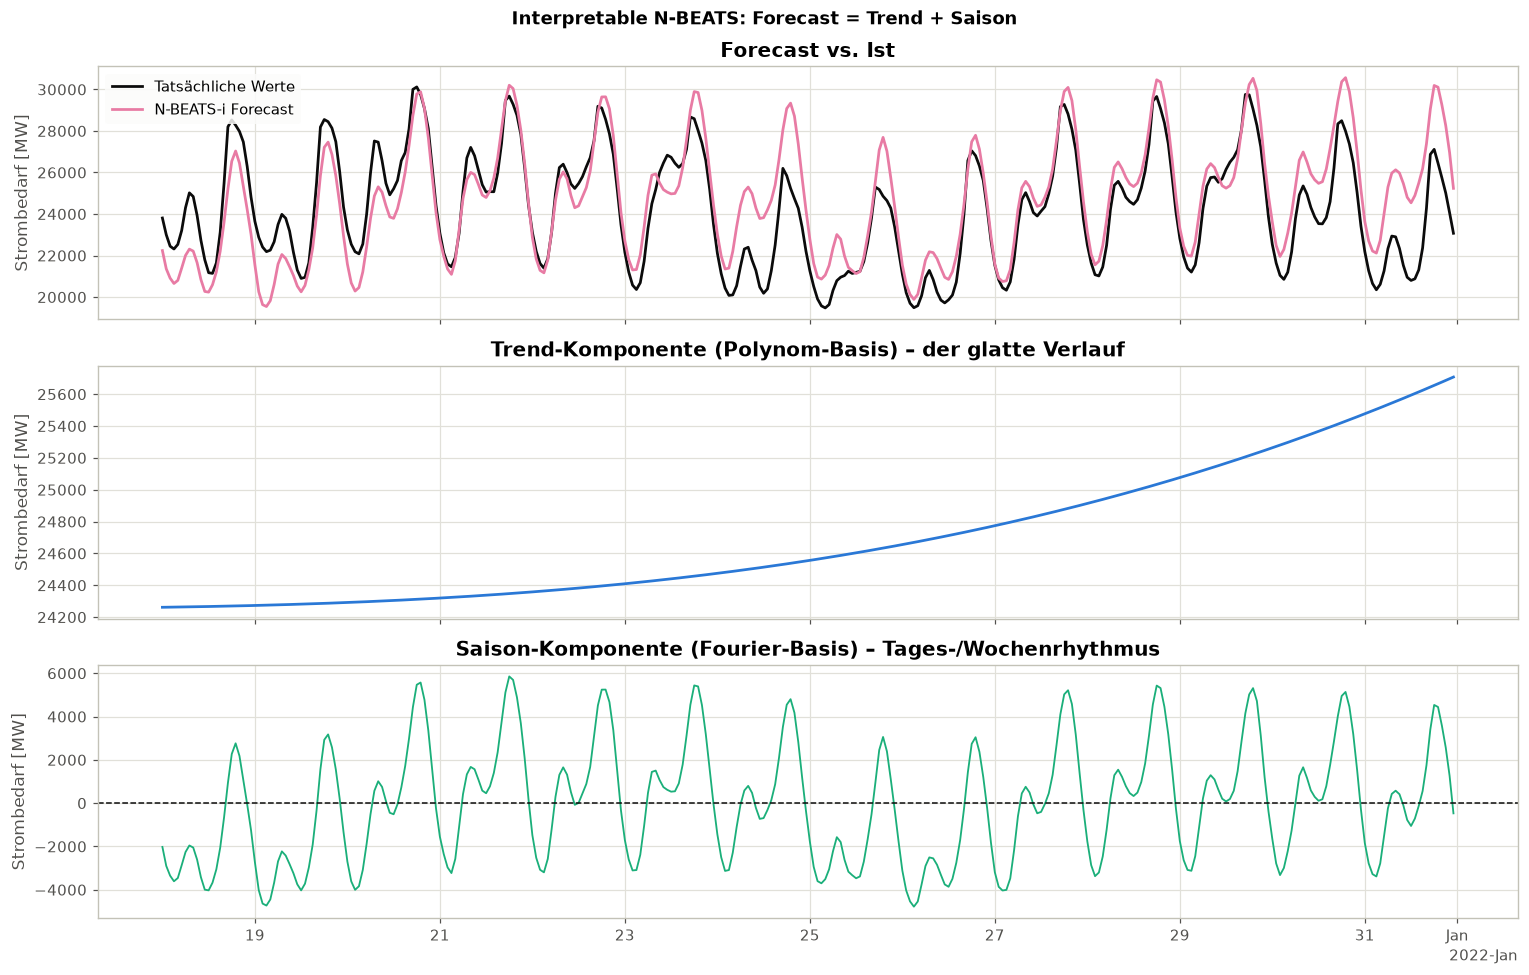

In [22]:
idx = y_test.index
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(idx, y_ist.values, color=FARBEN["Ist"], label="Tatsächliche Werte", linewidth=1.8)
axes[0].plot(idx, interp_forecast, color=FARBEN["N-BEATS-i"], label="N-BEATS-i Forecast", linewidth=1.8)
axes[0].set_title("Forecast vs. Ist")
axes[0].legend(loc="upper left")

axes[1].plot(idx, trend_mean, color=FARBEN["Trend"], linewidth=1.8)
axes[1].set_title("Trend-Komponente (Polynom-Basis) – der glatte Verlauf")

axes[2].plot(idx, seas_mean, color=FARBEN["Saison"], linewidth=1.2)
axes[2].axhline(0, color=FARBEN["Ist"], linestyle="--", linewidth=1)
axes[2].set_title("Saison-Komponente (Fourier-Basis) – Tages-/Wochenrhythmus")

for ax in axes:
    ax.set_ylabel("Strombedarf [MW]")
datum_achse(axes[2])
fig.suptitle("Interpretable N-BEATS: Forecast = Trend + Saison", fontweight="bold")
plt.tight_layout()
plt.show()

   Modell    RMSE  MAPE [%]
    ARIMA 3017.58     10.95
   SARIMA 2232.70      7.55
  SARIMAX 1814.88      5.72
  N-BEATS 1715.32      5.94
 N-BEATSx 1417.96      4.74
N-BEATS-i 1605.90      5.48


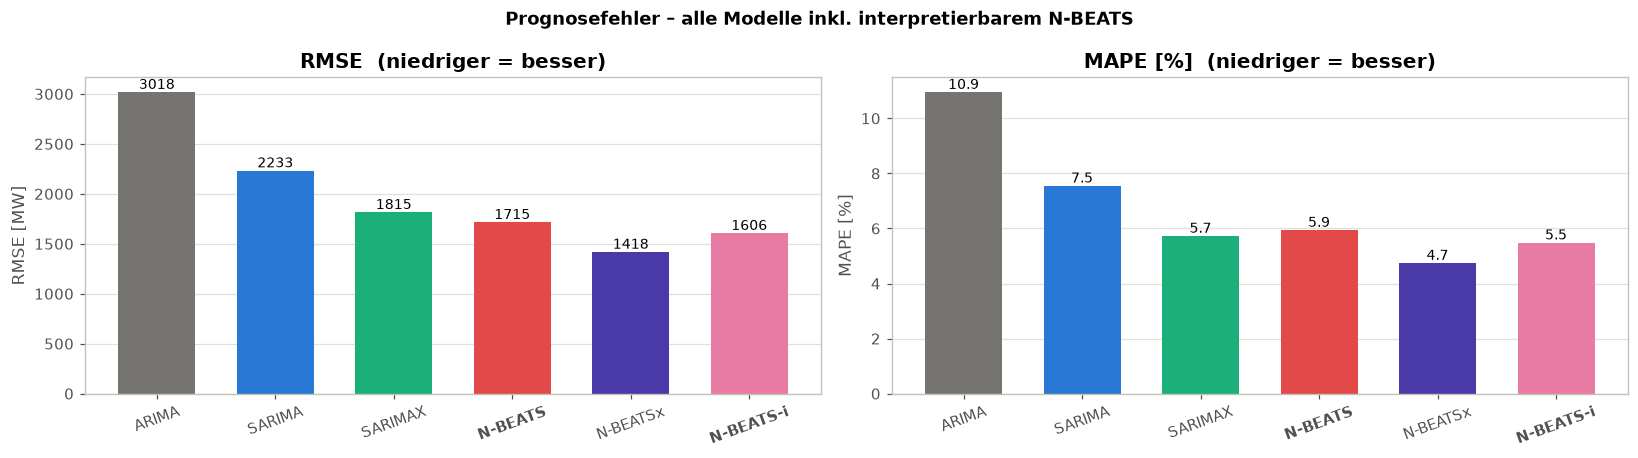

In [23]:
# Gesamtvergleich inkl. interpretierbarer Variante
alle6 = metrics_table(y_ist, {
    "ARIMA":     klassische_forecasts["ARIMA"],
    "SARIMA":    klassische_forecasts["SARIMA"],
    "SARIMAX":   klassische_forecasts["SARIMAX"],
    "N-BEATS":   nbeats_forecast,
    "N-BEATSx":  nbeatsx_forecast,
    "N-BEATS-i": interp_forecast,
})
print(alle6.round(2).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
for ax, metric in zip(axes, ["RMSE", "MAPE [%]"]):
    bars = ax.bar(alle6["Modell"], alle6[metric],
                  color=[FARBEN[m] for m in alle6["Modell"]], width=0.65)
    for bar, v in zip(bars, alle6[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, v,
                f"{v:.1f}" if "MAPE" in metric else f"{v:.0f}",
                ha="center", va="bottom", fontsize=9)
    ax.set_title(f"{metric}  (niedriger = besser)")
    ax.grid(False, axis="x")
    ax.tick_params(axis="x", rotation=20)
    # Achsenbeschriftung von N-BEATS und N-BEATS-i hervorheben
    for label in ax.get_xticklabels():
        if label.get_text() in ("N-BEATS", "N-BEATS-i"):
            label.set_fontweight("bold")
axes[0].set_ylabel("RMSE [MW]")
axes[1].set_ylabel("MAPE [%]")
fig.suptitle("Prognosefehler – alle Modelle inkl. interpretierbarem N-BEATS", fontweight="bold")
plt.tight_layout()
plt.show()

### 6.2 Interpretation N-BEATS-i

- **Zerlegbarkeit statt Blackbox:** Der Forecast wird sichtbar in **Trend** (glatter Verlauf) und **Saison** (Tages-/Wochenrhythmus) getrennt.
- **Interpretierbarkeit kostet etwas Genauigkeit:** N-BEATS-i liegt hinter generic N-BEATS, bei guter Modellierung ist der Unterschied jeoch gering. 
- **Höhere Seed-Varianz:** Die interpretierbare Variante streut über die Seeds stärker als generic → das **Ensemble-Mitteln** ist hier besonders wichtig.
- **Wann einsetzen:** **N-BEATSx** für maximale Genauigkeit. **N-BEATS-i**, wenn Stakeholder die Trend-/Saison-Komponenten nachvollziehen sollen und dafür etwas Genauigkeit geopfert werden darf.

<br>

----

## 7. Robustheits-Check: Walk-forward-Backtest

Alle bisherigen Zahlen beruhen auf **einem** Testfenster (den letzten 14 Tagen). \
Ein einzelner Split ist aber nur **eine Stichprobe** → ob das Fenster „leicht“ oder „schwer“ war ist Zufall. \
Ein **Walk-forward-Backtest** bewertet dasselbe Modell an **mehreren aufeinanderfolgenden Origins** (Ursprungspunkt) und zeigt, wie stark die Kennzahl schwankt.

**Vorgehen (Expanding Window):** Trainiere auf der gesamten Vergangenheit bis zum Origin, prognostiziere die nächsten 336 h, schiebe 14 Tage weiter, wiederhole. Immer nur auf der Vergangenheit trainieren → kein Leakage.

> ⚠️ **Kein Quervergleich zu den klassischen Modellen:** ARIMA/SARIMA/SARIMAX liegen nur für das **letzte** 14-Tage-Fenster vor. <br>
> **Zur Erinnerung – zwei verschiedene Streuungen:** Das **Ensemble** senkt die *Modell-/Seed-Varianz* (stabilere Prognose). Der **Walk-forward** senkt die *Schätz-Varianz* (verlässlichere Kennzahl). Sie ersetzen sich nicht, sondern ergänzen sich.

*Hinweis zur Rechenzeit: Dieser Abschnitt kombiniert Walk-forward **mit** dem Seed-Ensemble – an **jedem** Origin wird ein volles 5-Seed-Ensemble aller drei Varianten trainiert (die belastbare Variante)*

In [24]:
# ── Walk-forward-Backtest (Expanding Window) ──────────────────────────────────
# Renutzt die bestehenden Bausteine (train_one, Modelle, forward_*-Adapter,
# compute_metrics), damit die Trainingslogik identisch zum restlichen Notebook ist.

WF_ORIGINS = 4                  # aufeinanderfolgende 14-Tage-Fenster am Reihenende
WF_SEEDS   = ENSEMBLE_SEEDS     # volles Seed-Ensemble JE Origin (wie im Rest des Notebooks)

y_np = y.values                 # gesamte Zielreihe (float32) - Train+Test zusammen,
                                # da hier bei jedem Origin neu in Train/Test geschnitten wird
exog_np = exog_all.values       # exogene Variablen (float32) fuer N-BEATSx
Ltot = len(y_np)

def wf_scale(a):
    # eigene z-Standardisierung JE Origin: die mu/sd aus dem restlichen Notebook passen nur
    # zum originalen Split - hier hat jeder Origin seine eigene "Vergangenheit" (kein Leakage)
    m, s = float(a.mean()), float(a.std())
    return ((a - m) / s).astype("float32"), m, s

def wf_ensemble(build, loader, forward_batch, val_fn, forecast_fn):
    """Trainiert WF_SEEDS Modelle und mittelt die Forecasts (Rueckskalierung im forecast_fn).

    Gleiches Ensemble-Prinzip wie in den Abschnitten 3.4/5.3/6 - hier nur parametrisiert
    (build/forward_batch/val_fn/forecast_fn), damit dieselbe Funktion fuer alle drei
    N-BEATS-Varianten (generic, x, interpretable) wiederverwendet werden kann.
    """
    fcs = []
    for s in WF_SEEDS:
        torch.manual_seed(s)
        mdl = build().to(device)
        mdl, _, _ = train_one(mdl, loader, forward_batch, val_fn, seed=s)
        mdl.eval()
        with torch.no_grad():
            fcs.append(forecast_fn(mdl))
    return np.mean(fcs, axis=0)

rows = []
t0 = time.time()
for k in range(WF_ORIGINS):
    # Origin = letzte Trainingsstunde vor dem Testfenster; ruckt je Schleifendurchlauf um
    # HORIZON weiter. Der letzte Origin (k=WF_ORIGINS-1) entspricht exakt dem originalen
    # Testzeitraum aus Abschnitt 2.
    start = Ltot - (WF_ORIGINS - k) * HORIZON
    end   = start + HORIZON
    y_tr, y_te = y_np[:start], y_np[start:end]   # Training NUR auf der Vergangenheit dieses Origins
    ytr_s, mu_o, sd_o = wf_scale(y_tr)

    # Fenster + Holdout-Validierung (wie Abschnitt 3.1), pro Origin neu
    Xo, Yo = make_windows(ytr_s[:-HORIZON], INPUT_SIZE, HORIZON, STRIDE)
    loader_o = DataLoader(TensorDataset(torch.from_numpy(Xo), torch.from_numpy(Yo)),
                          batch_size=512, shuffle=True)
    vctx = torch.from_numpy(ytr_s[-(INPUT_SIZE + HORIZON):-HORIZON]).unsqueeze(0).to(device)
    vtgt = torch.from_numpy(ytr_s[-HORIZON:]).unsqueeze(0).to(device)
    xin  = torch.from_numpy(ytr_s[-INPUT_SIZE:]).unsqueeze(0).to(device)  # Kontext fuer den finalen Forecast

    # exogene Variablen fuer N-BEATSx (pro Origin neu skalieren, kein Leakage)
    ex_tr, ex_te = exog_np[:start], exog_np[start:end]
    sc_o = StandardScaler()
    ex_tr_s = sc_o.fit_transform(ex_tr).astype("float32")
    ex_te_s = sc_o.transform(ex_te).astype("float32")
    Yi, Xf, Yy = make_windows_x(ytr_s[:-HORIZON], ex_tr_s[:-HORIZON], INPUT_SIZE, HORIZON, STRIDE)
    loader_ox = DataLoader(TensorDataset(torch.from_numpy(Yi), torch.from_numpy(Xf), torch.from_numpy(Yy)),
                           batch_size=512, shuffle=True)
    vfut = torch.from_numpy(ex_tr_s[-HORIZON:].flatten()[np.newaxis, :]).to(device)
    xfut = torch.from_numpy(ex_te_s.flatten()[np.newaxis, :]).to(device)

    # Alle drei N-BEATS-Varianten fuer diesen Origin trainieren - KEINE klassischen Modelle:
    # ARIMA/SARIMA/SARIMAX liegen nur fuer den originalen Testzeitraum vor (s. Hinweis oben).
    fc = {}
    fc["N-BEATS"]  = wf_ensemble(
        lambda: NBeats(INPUT_SIZE, HORIZON, hidden=256, n_stacks=3, n_blocks=2),
        loader_o, forward_nbeats, lambda m: nn.functional.mse_loss(m(vctx), vtgt).item(),
        lambda m: m(xin).squeeze(0).cpu().numpy() * sd_o + mu_o)
    fc["N-BEATSx"] = wf_ensemble(
        lambda: NBeatsX(INPUT_SIZE, HORIZON, n_exog, hidden=256, n_stacks=3, n_blocks=2),
        loader_ox, forward_nbeatsx, lambda m: nn.functional.mse_loss(m(vctx, vfut), vtgt).item(),
        lambda m: m(xin, xfut).squeeze(0).cpu().numpy() * sd_o + mu_o)
    fc["N-BEATS-i"] = wf_ensemble(
        lambda: NBeatsInterpretable(INPUT_SIZE, HORIZON, hidden=256, degree=3, n_harmonics=96, n_blocks=3),
        loader_o, forward_interp, lambda m: nn.functional.mse_loss(m(vctx), vtgt).item(),
        lambda m: m(xin).squeeze(0).cpu().numpy() * sd_o + mu_o)

    for name, f in fc.items():
        rows.append({"Origin": k + 1, "Modell": name, **compute_metrics(y_te, f)})  # RMSE/MAPE je Origin+Modell
    print(f"Origin {k+1}/{WF_ORIGINS}  [{start}:{end}]  fertig", flush=True)

print(f"\nWalk-forward in {time.time()-t0:.0f}s ({WF_ORIGINS} Origins, {len(WF_SEEDS)} Seed(s))")
wf_df = pd.DataFrame(rows)
print(wf_df.round(2).to_string(index=False))

Origin 1/4  [24960:25296]  fertig
Origin 2/4  [25296:25632]  fertig
Origin 3/4  [25632:25968]  fertig
Origin 4/4  [25968:26304]  fertig

Walk-forward in 409s (4 Origins, 5 Seed(s))
 Origin    Modell    RMSE  MAPE [%]
      1   N-BEATS 1194.63      3.47
      1  N-BEATSx 1063.76      3.49
      1 N-BEATS-i 1237.54      4.13
      2   N-BEATS 1504.05      4.59
      2  N-BEATSx 1290.89      4.06
      2 N-BEATS-i 1628.03      5.05
      3   N-BEATS 1589.13      4.87
      3  N-BEATSx 1623.28      5.72
      3 N-BEATS-i 1393.99      4.28
      4   N-BEATS 1902.21      6.55
      4  N-BEATSx 1461.86      4.86
      4 N-BEATS-i 1897.56      6.59


             RMSE        MAPE [%]     
             mean    std     mean  std
Modell                                
N-BEATS    1547.5  291.0      4.9  1.3
N-BEATS-i  1539.3  287.7      5.0  1.1
N-BEATSx   1360.0  239.6      4.5  1.0


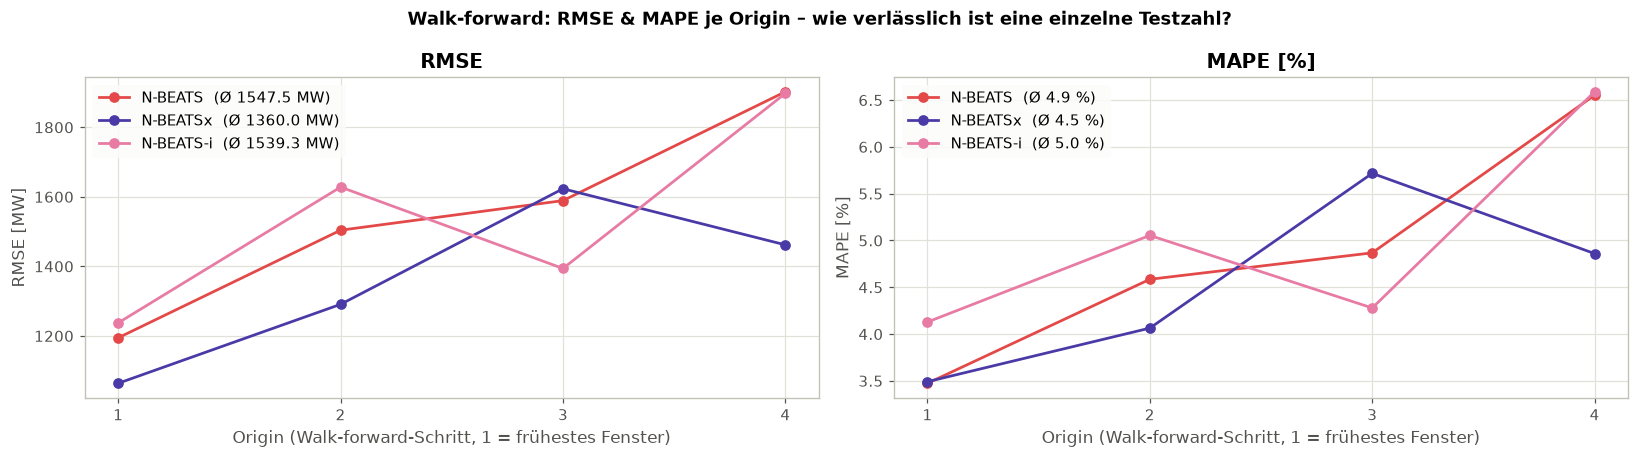

In [25]:
# Zusammenfassung: Mittel und Streuung je Modell über die Origins
summary = wf_df.groupby("Modell")[["RMSE", "MAPE [%]"]].agg(["mean", "std"]).round(1)
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(15, 4.2))
for ax, metric, einheit in zip(axes, ["RMSE", "MAPE [%]"], ["MW", "%"]):
    for name in ["N-BEATS", "N-BEATSx", "N-BEATS-i"]:
        sub = wf_df[wf_df["Modell"] == name].sort_values("Origin")
        mittel = sub[metric].mean()
        ax.plot(sub["Origin"], sub[metric], marker="o", markersize=6, linewidth=1.8,
                label=f"{name}  (Ø {mittel:.1f} {einheit})", color=FARBEN[name])
    ax.set_xlabel("Origin (Walk-forward-Schritt, 1 = frühestes Fenster)")
    ax.set_ylabel(f"{metric}{' [' + einheit + ']' if metric == 'RMSE' else ''}")
    ax.set_title(metric)
    ax.set_xticks(sorted(wf_df["Origin"].unique()))
    ax.legend()
fig.suptitle("Walk-forward: RMSE & MAPE je Origin – wie verlässlich ist eine einzelne Testzahl?", fontweight="bold")
plt.tight_layout()
plt.show()

### Interpretation Walk-forward-Backtest

- **Eine Testzahl ist nur eine Stichprobe:** Der Fehler **desselben** Modells schwankt über die Origins deutlich. Der Wert aus dem einen Testfenster (Abschnitt 4/5) kann also zufällig günstig oder ungünstig ausgefallen sein.
- **Robustere Aussage:** Das **Mittel über die Origins** (± Streuung) ist ein belastbarerer Schätzer der Prognosegüte als jeder Einzelwert → genau dafür gibt es den Walk-forward-Backtest.
- **Rangfolge prüfen:** Bleibt die Ordnung der Modelle über die Origins stabil, ist sie vertrauenswürdig. Kippt sie von Fenster zu Fenster, war der Vorsprung im Einzel-Split womöglich Zufall. Hier bleibt **N-BEATSx** im Mittel vorn und **N-BEATS-i** hinten, aber nicht in jedem einzelnen Fenster.
- **Kosten:** Der Backtest trainiert *Origins × Seeds × Modelle* Netze. Walk-forward **plus** volles Seed-Ensemble je Origin ist die belastbare, aber rechenintensive Kombination. In der Praxis wählt man Origins/Seeds nach verfügbarer Rechenzeit.

## 8. Fazit: Die wichtigsten Erkenntnisse

> ❓ **Leitfrage der Demo:** Kann ein universelles neuronales Netz, das **ohne** manuelle Stationaritäts- und Saisonalitätsanalyse auskommt, die klassischen (S)ARIMA(X)-Modelle erreichen oder übertreffen?
>
> ✅ **Antwort: Ja.** N-BEATS schlägt seinen fairen Partner SARIMA deutlich und erreicht SARIMAX-Niveau – ganz ohne Zeitreihenanalyse. Mit exogenen Variablen (**N-BEATSx**) ist es das stärkste Modell in unserem Vergleich.

### Was wir gelernt haben

| # | Erkenntnis | Konsequenz für die Praxis |
|---|---|---|
| 1 | **Trend & Saisonalität werden implizit gelernt** – keine Ordnungswahl, keine Stationaritätstests | Deutlich weniger Vorverarbeitung – dafür mehr Daten und Rechenzeit |
| 2 | **Exogene Variablen sind der größte Hebel** (N-BEATSx > N-BEATS, genau wie SARIMAX > SARIMA) | Gute externe Einflussgrößen bringen mehr als Feintuning am Modell |
| 3 | **Ein einzelner Trainingslauf ist Zufall** – die Seed-Streuung ist enorm | Das **Ensemble** ist Pflicht, nicht Kür |
| 4 | **Eine einzelne Testzahl ist nur eine Stichprobe** – der Fehler schwankt über die Origins | **Walk-forward-Backtest** statt Single-Split für belastbare Aussagen |
| 5 | **RMSE und MAPE bewerten unterschiedlich** – große Ausreißer vs. typischer relativer Fehler | Metrik nach Kostenbild wählen; im Zweifel **beide** berichten |
| 6 | **Interpretierbarkeit ist erkaufbar** – N-BEATS-i zerlegt den Forecast in Trend + Saison | Einsetzbar wenn Stakeholder die Komponenten brauchen |
| 7 | **Kein Modell hinterlässt „weißes Rauschen“** – die Residuen bleiben autokorreliert | Es bleibt Struktur übrig: Die Modellierung kann noch optimiert werden |
